# Общая задача: метод Ahmad et al. as-is против синергетического расширения, случайного, магнитудного и greedy backward прунинга

Воспроизводится top-down path selection из Ahmad et al. (WACV 2024, далее «статья»), затем добавляется правило расширения по знаку парного взаимодействия узлов. Цель ноутбука - сравнить **как метод отбора узлов для прунинга сети целиком** (общая задача, 10 классов): исходный алгоритм статьи as-is, его синергетическое расширение, случайный отбор, отбор по магнитуде и greedy backward. Сравнение проводится на **двух датасетах: MNIST и CIFAR-10**, на 5 независимо обученных сетях каждого.

Единица прунинга здесь - **узел** (фильтр, канал или нейрон), а не путь, как в самих интервенциях алгоритма: удалённый узел выбывает из сети целиком со всеми входящими и исходящими связями, поэтому методы сравниваются **при равном числе оставленных узлов на слой**, а не при равном числе занулённых весов. В сравнение, помимо исходного алгоритма и его расширения, включены сильные базовые линии - случайный отбор, отбор по магнитуде весов и greedy backward с перезамером после каждого удаления, - а также дообучение после отбора, оценка стоимости самого отбора и контроль на сети со случайными (необученными) весами. Отбор компактных подсетей для отдельных классов и их объединение через мета-модель рассмотрены отдельно, в `experiment_class_specific_task.ipynb`: там единица сравнения - не сеть целиком, а подсеть с одним выходом.

**Как читать.** Раздел 1 - ограничения, установленные до этого ноутбука, и где они здесь перепроверяются. Разделы 2-4 - теория и постановка. Раздел 5 - код. Раздел 6 - результаты. Раздел 7 - интерпретация и оценка идеи синергии.

## 1. Что установлено ранее и что нужно учитывать при чтении

Пять выводов из прошлых ноутбуков и отчётов (`experiment3_v2.ipynb`, `experiment5_cifar10.ipynb`, `work/CHECKPOINT_1.md`, `work/FINAL_REPORT.md`). Каждый перепроверяется числами этого ноутбука; ссылка на раздел стоит в скобках.

> **1. В малых сетях почти всё помечено как важное - запас для прунинга мал.** В v2 на MNIST критичными оказались 88% каналов `conv2` и 95% фильтров `conv1` (в среднем по классам); на CIFAR-10 (`experiment5`) 53% каналов `conv2` и 55% фильтров `conv1`. Схема as-is оставляет 60-76% весов, поэтому сравнение при естественном размере идёт в области, где даже случайные методы теряют мало. *(проверяется в 6.1, 6.4 и через запас H в 6.4)*
>
> **2. На MNIST доля «спасённых» связей мала, поэтому прирост метрик мог быть эффектом насыщения.** В v2 синергия добавила 2 узла из 57. *(6.2, 6.3)*
>
> **3. На CIFAR-10 выигрыш расширения объясняется размером схемы, а не отбором.** В `experiment5` контроль того же размера (первые узлы по наименьшему ATE) давал AUROC 0.802 против 0.815 у расширения. Именно для этого здесь есть контроли «as-is + случайное дополнение» и «as-is + топ-ATE дополнение». *(6.4)*
>
> **4. Неаддитивность пар узлов в необученных сетях сопоставима с обученными.** «Необученная сеть» - сеть той же архитектуры со случайными начальными весами, вообще без обучения; она служит нулевой моделью. В `work/CHECKPOINT_1.md` результат зависит от слоя и от теста: по строгому тесту с нулевой моделью у необученных доля неаддитивных пар выше в 3 из 4 переходов, в одном (TinyCifarNet `conv1 -> conv2`) выше у обученных; по тесту из ноутбуков (t-тест + BY + $\tau$) у обученных выше или равно в 3 из 4. Поэтому вывод формулируется как «неаддитивность в малых сетях не отделена от архитектуры», а не как «выше у необученных». *(6.7)*
>
> **5. Прунинг на основе взаимодействия проигрывает greedy backward по метрикам; вопрос стоимости остаётся открытым.** В `work/FINAL_REPORT.md` итеративный перезамер лучше всех. Здесь стоимость измеряется двумя способами: отбор (прямые проходы по изображениям и секунды) и работа прореженной сети (параметры, MAC и измеренная задержка). *(6.5, 6.6)*

Общее ограничение: обе сети малы (5.8 тыс. параметров у MNIST-сети, ~66 тыс. у CIFAR-сети), результаты не переносятся на глубокие сети без отдельной проверки.

In [1]:
# Установка зависимостей в окружение ядра (после установки torch может потребоваться перезапуск ядра)
%pip install -q numpy pandas matplotlib scipy statsmodels torch pyarrow pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: D:\jills projects\.venv\Scripts\python.exe -m pip install --upgrade pip


## 2. Теория: вмешательство на путях (по статье)

**Постановка (раздел 3.2 статьи, уравнение (1)).** Для узла $j$ родительского слоя обнуляются его исходящие веса $w_j^{l\to l+1}$ к выбранному подмножеству дочерних узлов ($n_t < n_c$), затем проверяется нулевая гипотеза $E[TE]=0$ на примерах класса. **Treatment effect (раздел 3.3, определение 1)** - разность логита до softmax при $\beta=0$ и $\beta=1$:
$$TE = z_k(do(w=0)) - z_k(w).$$
**Вмешательство** $u=\beta w$, $\beta\in\{0,1\}$ (в статье допускается и непрерывное $\beta\sim U(b-\epsilon,b+\epsilon)$ только для проверки надёжности, раздел 5.1; здесь используется бинарное). **Path selection (раздел 3.4, Algorithm 1):** идём от выхода к входу и вмешиваемся только в связи с уже отобранными целями следующего уровня; критичными (`critical`) считаются узлы со значимо отрицательным TE, вредными (`harmful`) - со значимо положительным. Тест двусторонний t-тест, $\alpha=0.05$, **без поправки на множественность** (как в статье).

**Почему вмешиваемся в пути, а не выключаем весь канал.** У нейрона может быть полезная связь с одной целью и нерелевантная с другой. Поэтому в статье обнуляются исходящие веса родителя только к выбранным целям: для `conv1 -> conv2` меняется срез `conv2.weight[targets, source]`, а не фильтр `conv1[source]`. При переходе `conv2 -> fc1` один канал `conv2` разворачивается в $s^2$ входов `fc1` (16 у MNIST-сети, 25 у CIFAR-сети), они выключаются единым блоком.

**Дополнительные критерии расширения** (в статье отсутствуют):

* *Поправка на множественность.* Benjamini-Yekutieli вместо BH: парные тесты делят между собой одни и те же величины $TE(A)$ и $TE(B)$, зависимость структурная.
* *Порог размера эффекта.* При $n\approx 10^2$ и малой дисперсии t-тест объявляет значимым эффект в $10^{-3}$ логита, не имеющий содержательного смысла. Поэтому вводится $\tau=\texttt{TAU\_REL}\cdot\mathrm{std}(z_k)$ (std по calibration-примерам класса на неизменённой сети); узел отобран, только если он проходит FDR и $|ATE|>\tau$. Значение фиксируется до просмотра результатов.

t-тест измеряет дисперсию TE **по входам**: нейрон, критичный для половины примеров класса и безразличный для другой половины, может не пройти тест. Поэтому в таблицах узлов хранится и доля примеров с $|TE|>\tau$ (`hit_rate`).

## 3. Теория: парные взаимодействия и правило расширения

Для пары путей $A,B$ потеря логита $L(A)=z_k(\text{original})-z_k(do(A=0))=-TE(A)$, и
$$S(A,B) = L(A\cup B) - L(A) - L(B).$$
Это коэффициент Мёбиуса второго порядка (дивиденд Харсаньи) для функции ценности «ущерб от абляции множества», то есть дискретная смешанная вторая разность; та же величина известна как interaction index второго порядка в теории кооперативных игр. Это **не** синергия в смысле partial information decomposition: мы не разлагаем взаимную информацию активаций, а измеряем нелинейность отклика фиксированной сети на весовые вмешательства.

**Знак $S$.** (Названия из `experiment5`: прежние «комплементарность/избыточность» вводили в заблуждение.)

* $S>0$ - **синергия**: совместное удаление вредит сильнее суммы отдельных удалений. Игрушечный пример: выход $=\max(a,j)$ при $a=j=1$ даёт $L=0,0$ и $L(\{a,j\})=1$, то есть $S=+1$.
* $S<0$ - **субаддитивность**: совместное удаление вредит слабее суммы; узлы делят общую зависимость (выход $=\min(a,j)$ даёт $L=1,1,1$ и $S=-1$).
* $S\approx0$ - аддитивность. Здесь «$S=0$» означает «не значимо после поправки BY при $n=128$ и порога $\tau$».

**Где $S$ может быть ненулевым.** На переходе `fc1 -> fc2` логит $z_k=\sum_j W^{fc2}_{kj}a_j+b_k$ линеен по вмешиваемым весам, поэтому $TE(A\cup B)=TE(A)+TE(B)$ и $S(A,B)\equiv0$ тождественно, с точностью до ошибки округления (в v2 численная проверка дала $\max|S|\sim10^{-6}$). Отсюда общий вывод о границах метода: **ненулевое $S$ может возникнуть только из нелинейностей (ReLU и max-pool) между вмешиваемыми весами и логитом.** Для `conv2 -> fc1` и `conv1 -> conv2` они есть, поэтому парный скрининг проводится только там; на `fc1 -> fc2` действует правило «$S=0$: остаются только `critical`».

**Ограничения.** Проверяются только пары внутри одного слоя. Нулевое парное взаимодействие не означает отсутствия взаимодействий более высокого порядка: три взаимно избыточных канала могут давать $S\approx0$ на каждой паре. Полный парный скрининг стоит $O(n^2)$ прямых проходов на слой.

### Правило расширения (по классу и слою)

Для класса $k$ на каждом слое (сверху вниз, цели следующего слоя равны итогу правила):

1. `critical` узлы (как в статье, но с поправкой BY и порогом $\tau$) попадают в цепь.
2. Пара с $S>0$ (значимо, $|S|>\tau$): **берём оба узла**.
3. Пара с $S<0$: **удаляем узел с меньшим вкладом в логит** ($-ATE$ меньше). Удаление приоритетнее добавления: узел, добавленный по $S>0$ и проигравший по $S<0$, удаляется (сигнал, что метка `critical` этого узла недостоверна). Удаления применяются **по убыванию $|S|$ и только пока оба узла пары ещё в цепи**: иначе цепочка $A>B>C$ удалила бы и $B$, и $C$, хотя $C$ избыточен только с уже удалённым $B$.
4. Пара с $S=0$ (в том числе все узлы на `fc1 -> fc2`): остаются только `critical`.
5. В слое всегда остаётся не менее одного узла (самый сильный по $-ATE$), иначе цепь пуста.

Знак вклада: $-ATE$ учитывает знак, поэтому `harmful` узел (ATE > 0) удаляется раньше `critical`. Для двух `critical` узлов это то же, что «меньший $|ATE|$».

Число добавленных (по $S>0$), удалённых (по $S<0$) и конфликтных узлов выводится как диагностика (раздел 6.2); отдельных «алгоритмов только добавления» и «только удаления» нет.

## 4. Постановка эксперимента

**Единица прунинга - узел** (фильтр `conv1`, канал `conv2`, нейрон `fc1`); выходной слой `fc2` сохраняется. Прореженная сеть = плотная сеть меньшей ширины: оставлены выбранные узлы и **все** связи между ними. Это отличает постановку от масок v2: там маска была по путям (`conv2.weight[targets, source]`), и после объединения по классам получалось объединение прямоугольников «цели класса $\times$ источники класса», которое оставляет только связи, проверенные интервенциями. Для цепи одного класса оба определения совпадают; при объединении узловой вариант оставляет и связи, которых ни одна цепь не проверяла. Доля весов в обоих вариантах выводится в 6.3 (диагностика). Выбор узлового варианта даёт реально меньшую плотную сеть: параметры, MAC и время инференса можно измерить, а не оценивать.

**Как получается набор узлов сети целиком.** Правило (или as-is) применяется к каждому из 10 классов; берётся объединение узлов по классам. Узлы, удалённые правилом для класса $k$, могут вернуться через цепь другого класса - доля таких возвратов измеряется (6.3).

**Методы (все узловые):**

| Метод | Как отбираются узлы |
|---|---|
| `as-is (статья)` | объединение по классам множеств `critical` (Algorithm 1, $p<\alpha$, без поправок) |
| `расширение (синергия)` | объединение по классам множеств правила из раздела 3 (BY, $\tau$, знак $S$); метод сам определяет размер, отдельного размера для него не задаётся |
| `расширение (ATE+синергия)` | то же правило, обобщённое на **произвольный размер** (нужно, чтобы сравнивать методы на одном размере, в том числе меньше или больше естественного): сначала узлы из `расширение (синергия)` по убыванию вклада в логит $-ATE$; дальше жадно добавляется узел с наибольшей суммарной синергией ($S>0$) к уже включённым узлам; когда синергетических партнёров не остаётся - обычный топ-$ATE$. При урезании до меньшего размера от этого же порядка просто берётся начало |
| `as-is + случайное дополнение` | контроль размера: as-is, у которого в каждом слое случайно добавлены (или случайно убраны) узлы до размера расширения |
| `as-is + топ-ATE дополнение` | сильный контроль размера: то же, но добавляются узлы с наибольшим вкладом $-ATE$ среди неотобранных (убираются с наименьшим); синергия здесь не используется - это чистое ранжирование по одиночному эффекту |
| `случайный (узлы)` | случайные узлы в каждом слое, то же число узлов на слой |
| `магнитуда (узлы)` | узлы с наибольшей $L_2$-нормой входящих весов (топ внутри слоя), то же число узлов на слой |
| `greedy backward` | на каждом шаге удаляется узел, после удаления которого точность на sel-выборке максимальна (перезамер после каждого шага); слои выбирает сам метод, размер сопоставляется по числу весов |
| `с нуля (та же форма)` | справочная строка: сеть той же ширины, обученная с нуля; отделяет ценность отобранных весов от ценности формы сети |

**Четыре размера сравнения.** (`A`) размер as-is; (`E`) размер расширения; (`S70`, `S40`) 70% и 40% узлов в каждом слое - «стресс-размеры»: естественные размеры близки к полной сети, и различия методов на них малы, а здесь есть запас (70% - для оценки без дообучения, где на 40% все методы падают до уровня случайного; 40% - для оценки с дообучением). Метод `расширение (ATE+синергия)` участвует во всех четырёх таблицах (в том числе на размере `A`, где естественного размера у него нет), чтобы синергия была видна в каждом сравнении, а не только на своём естественном размере `E`. Для методов, умеющих ранжировать (as-is по $-ATE$, расширение ATE+синергия, магнитуда, случайный, greedy), дополнительно строятся кривые точность - доля весов: это тот же критерий метода, принудительно применённый к сетке долей весов, а не только к своему естественному размеру.

**Две постановки качества.** *Без дообучения* (как в статье: раздел 6 отмечает, что метод «отличается от прунинга, который требует дообучения и настройки») и *с дообучением*: маска фиксирована структурно (обучается компактная сеть), 3 эпохи Adam на обучающей части, одинаково для всех методов. Первое измеряет, насколько удаление узлов ломает сеть; второе - какого качества достигает сеть меньшего размера при данном наборе узлов.

**Данные.** Обучение сети / отбор путей и greedy (sel-часть, только из train) / тест. Тест используется только для итоговых метрик. У MNIST: 12 000 обучающих, 8 000 sel; у CIFAR-10: 40 000 обучающих, 5 000 sel. Правильно классифицированные примеры класса для t-тестов берутся из sel-части случайно ($n=128$).

**Метрики (все на тесте).** Главная - accuracy; дополнительно macro-recall, минимальный recall по классам, доля совпадений предсказаний с исходной сетью (`agree`), доля весов и MAC относительно исходной сети. Сравнение методов - **парное по сетям** (5 обучений): разность с расширением по каждой сети и число побед; случайные линии усредняются по 20 розыгрышам (по 2 с дообучением). **Запас** $H=\text{acc}(\text{исходная})-\text{acc}(\text{случайная того же размера})$: если $H$ мал, различия методов на этом размере неинформативны.

## 5. Код

Ячейки ниже определяют данные, сеть, интервенции, правило, наборы узлов, компактную сеть и оценку. Результаты прогона (сети, цепи, таблицы) кэшируются в `cache/common/`, повторный запуск не пересчитывает отбор; чтобы пересчитать, удалите эту папку или задайте `USE_CACHE = False`.

In [2]:
# 0. Окружение, конфигурация, данные, модель
import sys, os, gzip, struct, io, time, pickle, random, warnings, shutil
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass
from itertools import combinations
from typing import Optional
from urllib.request import Request, urlopen, urlretrieve
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import torch, torch.nn as nn, torch.nn.functional as F
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)    # предупреждения sklearn о будущих изменениях API
warnings.filterwarnings('ignore', category=RuntimeWarning)   # t-тест на константном векторе (мёртвый узел) даёт nan, ниже он обрабатывается явно

# --- Конфигурация. Все пороги фиксируются здесь, до просмотра результатов. ---
QUICK       = os.environ.get('NB_QUICK') == '1'      # быстрый режим для отладки: 1 сеть, 1 датасет
SEEDS       = [42] if QUICK else [42, 0, 1, 2, 3]    # 5 независимых обучений сети на датасет
DATASETS    = os.environ['NB_DATASETS'].split(',') if os.environ.get('NB_DATASETS') else (['MNIST'] if QUICK else ['MNIST', 'CIFAR-10'])
ALPHA       = 0.05        # уровень значимости, как в статье
FDR_METHOD  = 'fdr_by'    # Benjamini-Yekutieli: парные тесты структурно зависимы
TAU_REL     = 0.02        # порог размера эффекта, в долях std логита класса
N_CAL       = 128         # правильно классифицированных примеров на класс для t-тестов
N_RANDOM    = 3 if QUICK else 20     # розыгрышей случайной линии без дообучения
N_RANDOM_FT = 1 if QUICK else 2      # розыгрышей случайной линии с дообучением
FT_EPOCHS   = 1 if QUICK else 3      # эпох дообучения при фиксированной маске
FT_LR       = 5e-4
CACHE_DIR   = Path('cache/common'); CACHE_DIR.mkdir(parents=True, exist_ok=True)
USE_CACHE   = True        # результаты (сеть, цепи, таблицы) на диске: повторный запуск не пересчитывает отбор

random.seed(42); np.random.seed(42); torch.manual_seed(42)
torch.use_deterministic_algorithms(True, warn_only=True)
device = torch.device('cpu')
torch.set_num_threads(4)
print('Python:', sys.executable); print('Device:', device, '| QUICK =', QUICK, '| seeds:', SEEDS, '| datasets:', DATASETS)

# Разбиение данных: обучение сети / отбор путей и greedy / обучение мета-модели (ноутбук 2) / тест. Тест не участвует ни в чём, кроме итоговых метрик.
DS = {
    'MNIST':    dict(in_ch=1, size=28, widths=(6, 10, 24),  s=4, n_train=12000, n_sel=8000, n_meta=10000, epochs=6,  greedy_n=1000, greedy_steps=36),
    'CIFAR-10': dict(in_ch=3, size=32, widths=(16, 32, 64), s=5, n_train=40000, n_sel=5000, n_meta=5000,  epochs=10, greedy_n=600,  greedy_steps=90),
}
if QUICK: DS['MNIST']['greedy_steps'] = 6
CLASS_NAMES = {'MNIST': [str(i) for i in range(10)],
               'CIFAR-10': ['самолёт', 'автомобиль', 'птица', 'кошка', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']}

def _load_mnist():
    root = Path('data/mnist_raw'); root.mkdir(parents=True, exist_ok=True)
    base = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    files = {'tr_x': 'train-images-idx3-ubyte.gz', 'tr_y': 'train-labels-idx1-ubyte.gz', 'te_x': 't10k-images-idx3-ubyte.gz', 'te_y': 't10k-labels-idx1-ubyte.gz'}
    for f in files.values():
        if not (root / f).exists(): urlretrieve(base + f, root / f)
    def img(p):
        with gzip.open(root / p, 'rb') as f:
            _, n, r, c = struct.unpack('>IIII', f.read(16)); return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, 1, r, c).copy()
    def lab(p):
        with gzip.open(root / p, 'rb') as f:
            f.read(8); return np.frombuffer(f.read(), dtype=np.uint8).astype(np.int64).copy()
    return img(files['tr_x']), lab(files['tr_y']), img(files['te_x']), lab(files['te_y'])

def _load_cifar():
    root = Path('data/cifar10_raw'); root.mkdir(parents=True, exist_ok=True); npz = root / 'cifar10_u8.npz'
    if not npz.exists():
        from PIL import Image
        base = 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/'
        out = {}
        for split, name in [('train', 'train-00000-of-00001.parquet'), ('test', 'test-00000-of-00001.parquet')]:
            path = root / f'cifar10_{split}.parquet'
            if not path.exists():
                with urlopen(Request(base + name, headers={'User-Agent': 'Mozilla/5.0'}), timeout=120) as r, open(path, 'wb') as f: shutil.copyfileobj(r, f)
            df = pd.read_parquet(path)
            out[f'x_{split}'] = np.ascontiguousarray(np.stack([np.array(Image.open(io.BytesIO(d['bytes'])).convert('RGB')) for d in df['img']]).transpose(0, 3, 1, 2))
            out[f'y_{split}'] = df['label'].to_numpy(dtype=np.int64)
        np.savez(npz, **out)
    z = np.load(npz); return z['x_train'], z['y_train'], z['x_test'], z['y_test']

class Data:
    """Изображения хранятся как uint8 и нормируются по батчам (экономия памяти на CPU)."""
    MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1); STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)
    def __init__(self, name):
        self.name, self.cfg = name, DS[name]
        xtr, ytr, xte, yte = _load_mnist() if name == 'MNIST' else _load_cifar()
        self.xtr, self.ytr, self.xte, self.yte = map(torch.from_numpy, (xtr, ytr, xte, yte))
        c = self.cfg; perm = torch.randperm(len(self.ytr), generator=torch.Generator().manual_seed(42))
        a, b, d = c['n_train'], c['n_train'] + c['n_sel'], c['n_train'] + c['n_sel'] + c['n_meta']
        self.train_idx, self.sel_idx, self.meta_idx = perm[:a], perm[a:b], perm[b:d]
        self.classes = CLASS_NAMES[name]
    def prep(self, xu8):
        x = xu8.float().div_(255)
        return x if self.name == 'MNIST' else (x - self.MEAN) / self.STD
    def x_train(self, idx): return self.prep(self.xtr[idx])
    def y_train(self, idx): return self.ytr[idx]

class ConvNet(nn.Module):
    """conv1 -> pool -> conv2 -> pool -> fc1 -> fc2. Ширины (c1, c2, f1) параметризованы, чтобы собирать компактные сети после удаления узлов."""
    def __init__(self, in_ch, widths, s, n_out=10):
        super().__init__(); c1, c2, f1 = widths; self.s = s
        self.conv1 = nn.Conv2d(in_ch, c1, 5); self.conv2 = nn.Conv2d(c1, c2, 5)
        self.fc1 = nn.Linear(c2 * s * s, f1); self.fc2 = nn.Linear(f1, n_out)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2); x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

def new_net(data, widths=None, n_out=10, seed=None):
    if seed is not None: torch.manual_seed(seed)
    return ConvNet(data.cfg['in_ch'], widths or data.cfg['widths'], data.cfg['s'], n_out).to(device)

def train_net(net, data, epochs, lr, seed, loss_fn=None, target=None):
    """Обучение на train-части. Используется и для исходной сети, и для дообучения компактных сетей (маска фиксирована структурно)."""
    g = torch.Generator().manual_seed(seed); opt = torch.optim.Adam(net.parameters(), lr=lr); idx = data.train_idx
    for _ in range(epochs):
        net.train(); order = torch.randperm(len(idx), generator=g)
        for i in range(0, len(idx), 128):
            b = idx[order[i:i + 128]]; xb, yb = data.x_train(b), data.y_train(b)
            opt.zero_grad(); out = net(xb)
            loss = F.cross_entropy(out, yb) if loss_fn is None else loss_fn(out, (yb == target).float())
            loss.backward(); opt.step()
    return net.eval()

@torch.no_grad()
def logits_on(net, xu8, data, batch=2500):
    net.eval(); return torch.cat([net(data.prep(xu8[i:i + batch])) for i in range(0, len(xu8), batch)])

def build_and_train(data, seed):
    net = new_net(data, seed=seed)
    return train_net(net, data, data.cfg['epochs'], 1e-3, seed)

Python: D:\jills projects\.venv\Scripts\python.exe
Device: cpu | QUICK = False | seeds: [42, 0, 1, 2, 3] | datasets: ['MNIST', 'CIFAR-10']


In [3]:
# 1. Path-интервенции (Algorithm 1 статьи) и правило расширения по знаку взаимодействия S
METER = {'images': 0}                      # счётчик прямых проходов по изображениям: аппаратно-независимая мера стоимости отбора
def fwd(net, x):
    METER['images'] += len(x); return net(x)

def stages_for(cfg):
    """(parent, child, n_parent, spatial_block, nonlinear_after). fc1 -> fc2: логит линеен по fc2.weight[k, :], значит S = 0 тождественно."""
    c1, c2, f1 = cfg['widths']; s2 = cfg['s'] ** 2
    return [('fc1', 'fc2', f1, None, False), ('conv2', 'fc1', c2, s2, True), ('conv1', 'conv2', c1, None, True)]

def module_of(net, name): return dict(net.named_modules())[name]

@torch.no_grad()
def logits_with_removed_paths(net, x, interventions):
    """do(w=0) для групп исходящих путей узла к выбранным целям, с полным восстановлением весов (β=0, как в Algorithm 1)."""
    backups = []
    try:
        for parent, child, source, targets, block in interventions:
            w = module_of(net, child).weight; targets = list(targets)
            index = (targets, source) if block is None else (targets, slice(source * block, (source + 1) * block))
            backups.append((w, index, w[index].detach().clone())); w[index] = 0
        return fwd(net, x)
    finally:
        for w, index, saved in reversed(backups): w[index] = saved

def fdr(rows, alpha, method):
    """method=None: статья as-is (сырое p < alpha, без поправки на множественность). 'fdr_by': расширение."""
    if not rows: return rows
    if method is None:
        for r in rows: r['p_fdr'], r['significant'] = float(r['p']), bool(r['p'] < alpha)
        return rows
    reject, p_adj, _, _ = multipletests([r['p'] for r in rows], alpha=alpha, method=method)
    for r, ok, p in zip(rows, reject, p_adj): r['p_fdr'], r['significant'] = float(p), bool(ok)
    return rows

def mean_test(values, tau):
    _, p = stats.ttest_1samp(values, 0.0)
    return {'ate': float(np.mean(values)), 'std': float(np.std(values, ddof=1)), 'p': float(np.nan_to_num(p, nan=1.0)), 'hit_rate': float(np.mean(np.abs(values) > tau))}

@torch.no_grad()
def calib_examples(net, data, class_id, n=N_CAL, seed=42, require_correct=True):
    """Случайные примеры класса из sel-части (не из теста). Для обученной сети - только правильно классифицированные (как в статье)."""
    cand = data.sel_idx[data.ytr[data.sel_idx] == class_id]
    if require_correct:
        cand = cand[logits_on(net, data.xtr[cand], data).argmax(1) == class_id]
    if len(cand) < 16: raise RuntimeError(f'Мало примеров класса {class_id}: {len(cand)}')
    pick = torch.randperm(len(cand), generator=torch.Generator().manual_seed(seed + class_id))[:n]
    return data.prep(data.xtr[cand[pick]])

@dataclass(frozen=True)
class AlgoConfig:
    """correction: None - как в статье; 'fdr_by' - расширение. tau_rel: порог размера эффекта (0 - выключен, как в статье).
    pair_screen: парный скрининг S и правило по знаку (расширение, в статье отсутствует)."""
    name: str
    correction: Optional[str] = None
    tau_rel: float = 0.0
    pair_screen: bool = False
    alpha: float = ALPHA

PAPER_ASIS = AlgoConfig('as-is', correction=None, tau_rel=0.0, pair_screen=False)
EXT        = AlgoConfig('ext',   correction=FDR_METHOD, tau_rel=TAU_REL, pair_screen=True)

def apply_sign_rule(ate, critical, pairs):
    """Правило расширения для одного класса и одного слоя.
       S>0 (синергия): берём оба узла.  S<0 (субаддитивность): удаляем узел с меньшим вкладом в логит (вклад = -ATE).
       S=0 (аддитивность): остаётся только critical.
       Конфликт (узел добавлен по S>0 и проигрывает по S<0): удаление приоритетнее добавления.
       Удаления идут по убыванию |S| и только пока ОБА узла пары ещё в цепи: иначе цепочка A>B>C удалила бы и B, и C,
       хотя C избыточен лишь с уже удалённым B."""
    syn_nodes = {n for r in pairs if r['sign'] == 'synergy' for n in (r['a'], r['b'])}
    keep = set(critical) | syn_nodes; removed = []
    for r in sorted([r for r in pairs if r['sign'] == 'subadditive'], key=lambda r: -abs(r['S'])):
        a, b = r['a'], r['b']
        if a not in keep or b not in keep: continue
        la, lb = -ate[a], -ate[b]
        loser = a if (la < lb or (la == lb and a > b)) else b       # меньший вклад в логит; при равенстве - больший индекс
        keep.discard(loser); removed.append(loser)
    added = syn_nodes - set(critical)
    return sorted(keep), sorted(syn_nodes), sorted(added), sorted(removed), sorted(set(removed) & syn_nodes)

def infer_class(net, data, class_id, algo, require_correct=True):
    """Top-down восстановление причинного подграфа одного класса: fc1 -> fc2, conv2 -> fc1, conv1 -> conv2.
    algo=PAPER_ASIS - Algorithm 1 as-is. algo=EXT - плюс поправка BY, порог tau и правило по знаку S."""
    net.eval(); stages = stages_for(data.cfg); x = calib_examples(net, data, class_id, require_correct=require_correct)
    with torch.no_grad(): baseline = fwd(net, x)[:, class_id].cpu().numpy()
    tau = algo.tau_rel * float(np.std(baseline, ddof=1)); targets, out = [class_id], []
    for parent, child, n_parent, block, nonlinear in stages:
        singles, te_cache = [], {}
        for s in range(n_parent):
            te = logits_with_removed_paths(net, x, [(parent, child, s, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
            te_cache[s] = te; singles.append(mean_test(te, tau))
        fdr(singles, algo.alpha, algo.correction)
        ate = np.array([r['ate'] for r in singles])
        for r in singles:
            keep_ = r['significant'] and abs(r['ate']) > tau
            r['role'] = 'critical' if keep_ and r['ate'] < 0 else 'harmful' if keep_ and r['ate'] > 0 else 'neutral'
        critical = [s for s, r in enumerate(singles) if r['role'] == 'critical']; harmful = [s for s, r in enumerate(singles) if r['role'] == 'harmful']
        pairs = []
        if algo.pair_screen and nonlinear:
            for a, b in combinations(range(n_parent), 2):
                te_j = logits_with_removed_paths(net, x, [(parent, child, a, tuple(targets), block), (parent, child, b, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
                r = mean_test(-te_j + te_cache[a] + te_cache[b], tau); r.update(a=a, b=b, S=r['ate']); pairs.append(r)   # S = L(A+B) - L(A) - L(B), L = -TE
            fdr(pairs, algo.alpha, algo.correction)
            for r in pairs:
                ok = r['significant'] and abs(r['S']) > tau
                r['sign'] = 'synergy' if ok and r['S'] > 0 else 'subadditive' if ok and r['S'] < 0 else 'additive'
        if algo.pair_screen:
            chosen, syn_nodes, added, removed, conflict = apply_sign_rule(ate, critical, pairs)
        else:
            chosen, syn_nodes, added, removed, conflict = list(critical), [], [], [], []
        if not chosen: chosen = [int(np.argmin(ate))]            # не менее одного узла на слой, иначе цепь пуста
        out.append({'parent': parent, 'child': child, 'targets': tuple(targets), 'n_parent': n_parent, 'ate': ate,
                    'p_fdr': np.array([r['p_fdr'] for r in singles]), 'critical': critical, 'harmful': harmful,
                    'synergy_nodes': syn_nodes, 'added': added, 'removed': removed, 'conflict': conflict,
                    'n_pairs': len(pairs), 'n_syn': sum(r['sign'] == 'synergy' for r in pairs), 'n_sub': sum(r['sign'] == 'subadditive' for r in pairs),
                    'pair_S': np.array([r['S'] for r in pairs], dtype=np.float32), 'pair_sign': [r['sign'] for r in pairs],
                    'chosen': chosen})
        targets = chosen
    return {'class': class_id, 'algo': algo.name, 'tau': tau, 'stages': out}

def infer_all(net, data, algo, classes=range(10), require_correct=True):
    """Цепи всех классов + стоимость отбора (прямые проходы по изображениям и секунды)."""
    METER['images'] = 0; t0 = time.perf_counter()
    circ = {c: infer_class(net, data, c, algo, require_correct) for c in classes}
    return circ, {'images': METER['images'], 'seconds': time.perf_counter() - t0}

In [4]:
# 2. Единица прунинга - УЗЕЛ. Наборы узлов, компактная сеть, размер, базовые методы, greedy backward, оценка
LAYERS3 = ['conv1', 'conv2', 'fc1']            # прореживаемые слои: фильтры conv1, каналы conv2, нейроны fc1 (выходной слой fc2 сохраняется)

def full_counts(cfg): return dict(zip(LAYERS3, cfg['widths']))

def eff_weights(cfg, counts, n_out=10):
    """Число весов плотной сети из оставленных узлов (без bias)."""
    s2 = cfg['s'] ** 2
    return {'conv1': counts['conv1'] * cfg['in_ch'] * 25, 'conv2': counts['conv2'] * counts['conv1'] * 25,
            'fc1': counts['fc1'] * counts['conv2'] * s2, 'fc2': n_out * counts['fc1']}

def macs(cfg, counts, n_out=10):
    ho1 = cfg['size'] - 4; ho2 = ho1 // 2 - 4; w = eff_weights(cfg, counts, n_out)
    return w['conv1'] * ho1 * ho1 + w['conv2'] * ho2 * ho2 + w['fc1'] + w['fc2']

def share(cfg, counts, n_out=10):
    """Доли весов и MAC компактной сети относительно исходной."""
    full = full_counts(cfg)
    return sum(eff_weights(cfg, counts, n_out).values()) / sum(eff_weights(cfg, full, n_out).values()), macs(cfg, counts, n_out) / macs(cfg, full, n_out)

@torch.no_grad()
def compact_net(net, cfg, sets, out_rows=None):
    """Собирает плотную сеть меньшей ширины из оставленных узлов. Эквивалентна обнулению исходящих весов удалённых узлов (проверяется в ячейке-тесте)."""
    i1, i2, i3 = (torch.tensor(sorted(sets[l]), dtype=torch.long) for l in LAYERS3); s2 = cfg['s'] ** 2
    rows = torch.arange(net.fc2.out_features) if out_rows is None else torch.tensor(sorted(out_rows), dtype=torch.long)
    out = ConvNet(cfg['in_ch'], (len(i1), len(i2), len(i3)), cfg['s'], len(rows))
    out.conv1.weight.copy_(net.conv1.weight[i1]); out.conv1.bias.copy_(net.conv1.bias[i1])
    out.conv2.weight.copy_(net.conv2.weight[i2][:, i1]); out.conv2.bias.copy_(net.conv2.bias[i2])
    cols = (i2[:, None] * s2 + torch.arange(s2)[None, :]).flatten()
    out.fc1.weight.copy_(net.fc1.weight[i3][:, cols]); out.fc1.bias.copy_(net.fc1.bias[i3])
    out.fc2.weight.copy_(net.fc2.weight[rows][:, i3]); out.fc2.bias.copy_(net.fc2.bias[rows])
    return out.to(device).eval()

@torch.no_grad()
def masked_full_net(net, cfg, sets):
    """Тот же результат через обнуление исходящих весов удалённых узлов в полной сети (для теста эквивалентности и для greedy)."""
    out = deepcopy(net).eval(); s2 = cfg['s'] ** 2
    for j in set(range(net.conv1.out_channels)) - set(sets['conv1']): out.conv2.weight[:, j] = 0
    for j in set(range(net.conv2.out_channels)) - set(sets['conv2']): out.fc1.weight[:, j * s2:(j + 1) * s2] = 0
    for j in set(range(net.fc1.out_features)) - set(sets['fc1']): out.fc2.weight[:, j] = 0
    return out

def counts_of(sets): return {l: len(sets[l]) for l in LAYERS3}

# ---------- наборы узлов разных методов ----------
def circuits_union(circuits):
    """Объединение узлов по классам и оценка узла = максимум по классам из (-ATE): вклад узла в логит самого зависимого класса."""
    sets, score = {}, {}
    for l in LAYERS3:
        st = [s for c in circuits.values() for s in c['stages'] if s['parent'] == l]
        sets[l] = sorted(set().union(*[set(s['chosen']) for s in st])); score[l] = np.max([-s['ate'] for s in st], axis=0)
    return sets, score

def ranked_sets(score, member, counts):
    """Топ по ATE внутри слоя: сначала члены множества метода (по убыванию -ATE), затем остальные узлы. При размере = |множество| совпадает с самим множеством.
    Синергию НЕ использует - это чистый ранжир по вкладу в логит; нужен как контроль «as-is + топ-ATE дополнение» и как критерий `as-is (топ-ATE)`."""
    out = {}
    for l in LAYERS3:
        order = sorted(range(len(score[l])), key=lambda j: (j not in member[l], -score[l][j], j)); out[l] = sorted(order[:counts[l]])
    return out

def layer_synergy_map(circuits, parent, n_parent):
    """Суммарная сила синергии (S>0) между парой узлов слоя, просуммированная по всем классам, где эта пара значимо синергична."""
    combo = list(combinations(range(n_parent), 2)); total = {}
    for circ in circuits.values():
        st = next((s for s in circ['stages'] if s['parent'] == parent), None)
        if st is None or not len(st['pair_S']): continue
        for (a, b), S, sign in zip(combo, st['pair_S'], st['pair_sign']):
            if sign == 'synergy': total[(a, b)] = total.get((a, b), 0.0) + float(S)
    return total

def interaction_fill_order(n_parent, score, syn_map, base_members):
    """Полный порядок узлов слоя для метода `расширение (ATE+синергия)`. Правило расширения (раздел 3) даёт узлы только
    на своём естественном размере; здесь оно обобщено на произвольный размер, чтобы синергия участвовала и на других
    размерах, а не подменялась чистым топ-ATE (как раньше делал `ranked_sets`).
    Сначала идут узлы естественной цепи расширения `base_members` (по убыванию вклада в логит -ATE). Дальше на каждом
    шаге добавляется узел с наибольшей суммарной синергией (S>0) с уже включёнными узлами - то есть цепь растёт вдоль
    найденных синергетических связей; когда партнёров с положительной синергией не остаётся, добавление продолжается
    обычным топ-ATE. Чтобы получить набор меньшего размера, от этого же порядка просто берётся начало: младшие члены
    естественной цепи (по -ATE) отбрасываются первыми, синергия влияет только на то, какие узлы ДОБАВЛЯЮТСЯ сверх неё."""
    order = sorted(base_members, key=lambda j: -score[j]); included = set(order)
    remaining = [j for j in range(n_parent) if j not in included]
    adj = {}
    for (a, b), S in syn_map.items():
        adj.setdefault(a, []).append((b, S)); adj.setdefault(b, []).append((a, S))
    while remaining:
        gains = {j: sum(S for p, S in adj.get(j, []) if p in included) for j in remaining}
        best_gain = max(gains.values(), default=0.0)
        cands = [j for j in remaining if gains[j] == best_gain] if best_gain > 0 else remaining
        best = max(cands, key=lambda j: score[j])
        order.append(best); included.add(best); remaining.remove(best)
    return order

def interaction_orders(cfg, ext, score, base):
    """order[слой] - полный порядок узлов слоя по критерию `расширение (ATE+синергия)` (interaction_fill_order); считается один раз на сеть."""
    full = full_counts(cfg)
    return {l: interaction_fill_order(full[l], score[l], layer_synergy_map(ext, l, full[l]), base[l]) for l in LAYERS3}

def interaction_sets(orders, counts):
    """Набор узлов слоя нужного размера из уже посчитанного interaction_orders (просто префикс)."""
    return {l: sorted(orders[l][:counts[l]]) for l in LAYERS3}

def random_sets(cfg, counts, rng):
    return {l: sorted(rng.choice(cfg['widths'][i], counts[l], replace=False).tolist()) for i, l in enumerate(LAYERS3)}

def random_adjust(cfg, base, counts, rng):
    """as-is + случайное дополнение: если слой меньше цели - добавляем случайные узлы; если больше - случайно убираем."""
    out = {}
    for i, l in enumerate(LAYERS3):
        b = list(base[l]); n = counts[l]
        if n >= len(b):
            rest = [j for j in range(cfg['widths'][i]) if j not in set(b)]; b = b + rng.choice(rest, n - len(b), replace=False).tolist() if n > len(b) else b
        else: b = rng.choice(b, n, replace=False).tolist()
        out[l] = sorted(b)
    return out

def magnitude_sets(net, counts):
    """Магнитуда по узлам: L2-норма входящих весов узла (фильтра/нейрона), топ внутри слоя."""
    out = {}
    for l in LAYERS3:
        w = module_of(net, l).weight.detach(); norm = w.flatten(1).norm(dim=1)
        out[l] = sorted(torch.topk(norm, counts[l]).indices.tolist())
    return out

def outgoing(net, cfg, layer, j):
    s2 = cfg['s'] ** 2
    return {'fc1': (net.fc2.weight, (slice(None), j)), 'conv2': (net.fc1.weight, (slice(None), slice(j * s2, (j + 1) * s2))),
            'conv1': (net.conv2.weight, (slice(None), j))}[layer]

@torch.no_grad()
def greedy_backward(net, data, max_steps, stop_share=0.10):
    """Greedy backward: на каждом шаге удаляется узел (исходящие веса в ноль), после удаления которого кросс-энтропия на sel-выборке минимальна
    (при равенстве - выше точность). Перезамер после каждого шага. Единица - узел любого из трёх слоёв, слои выбираются самим методом; в слое остаётся не менее одного узла.
    Критерий - кросс-энтропия, а не точность: точность на нескольких сотнях картинок шумная (в отладочном прогоне метод убирал живые узлы, случайно повышавшие точность на sel).
    Останавливается, когда доля весов сети опускается до stop_share или после max_steps шагов."""
    cfg = data.cfg; idx = data.sel_idx[:cfg['greedy_n']]; x = data.x_train(idx); y = data.ytr[idx]
    work = deepcopy(net).eval(); remaining = [(l, j) for i, l in enumerate(LAYERS3) for j in range(cfg['widths'][i])]; order = []
    left = full_counts(cfg); METER['images'] = 0; t0 = time.perf_counter()
    for _ in range(max_steps):
        best, best_key = None, None
        for u in remaining:
            if left[u[0]] <= 1: continue
            w, ix = outgoing(work, cfg, *u); saved = w[ix].clone(); w[ix] = 0
            out = fwd(work, x); key = (-F.cross_entropy(out, y).item(), (out.argmax(1) == y).float().mean().item()); w[ix] = saved
            if best_key is None or key > best_key: best, best_key = u, key
        w, ix = outgoing(work, cfg, *best); w[ix] = 0; order.append(best); remaining.remove(best); left[best[0]] -= 1
        if share(cfg, left)[0] <= stop_share: break
    return order, {'images': METER['images'], 'seconds': time.perf_counter() - t0}

def greedy_sets(cfg, order, L):
    gone = set(order[:L]); return {l: [j for j in range(cfg['widths'][i]) if (l, j) not in gone] for i, l in enumerate(LAYERS3)}

def greedy_match(cfg, order, target_w):
    """Длина префикса greedy, при которой число весов ближе всего к target_w (greedy сам выбирает распределение по слоям)."""
    best = min(range(len(order) + 1), key=lambda L: abs(sum(eff_weights(cfg, counts_of(greedy_sets(cfg, order, L))).values()) - target_w)); return best

def uniform_counts(cfg, f): return {l: max(1, int(round(f * n))) for l, n in full_counts(cfg).items()}

# ---------- оценка ----------
def path_union_share(cfg, circuits):
    """Диагностика: доля весов при маске v2 (объединение путей, найденных интервенциями) - для сравнения с подматрицей оставленных узлов."""
    s2 = cfg['s'] ** 2; c1, c2, f1 = cfg['widths']; conv2, fc1, fc2 = set(), set(), set(); n1 = set()
    for c in circuits.values():
        st = {s['parent']: s for s in c['stages']}
        n1 |= set(st['conv1']['chosen'])
        conv2 |= {(t, j) for t in st['conv1']['targets'] for j in st['conv1']['chosen']}
        fc1 |= {(t, j) for t in st['conv2']['targets'] for j in st['conv2']['chosen']}
        fc2 |= {(c['class'], j) for j in st['fc1']['chosen']}
    total = sum(eff_weights(cfg, full_counts(cfg)).values())
    return (len(n1) * cfg['in_ch'] * 25 + len(conv2) * 25 + len(fc1) * s2 + len(fc2)) / total

@torch.no_grad()
def eval_net(net, data, ref_pred=None):
    lg = logits_on(net, data.xte, data); pred = lg.argmax(1); y = data.yte
    rec = torch.stack([(pred[y == c] == c).float().mean() for c in range(10)])
    out = {'acc': float((pred == y).float().mean()), 'macro_recall': float(rec.mean()), 'min_recall': float(rec.min()), 'nll': float(F.cross_entropy(lg, y))}
    if ref_pred is not None: out['agree'] = float((pred == ref_pred).float().mean())
    return out

def time_infer(net, data, batch, reps=None):
    """Медиана времени прямого прохода, мс (1 поток, чтобы измерять вычисления, а не накладные расходы потоков)."""
    prev = torch.get_num_threads(); torch.set_num_threads(1); x = data.prep(data.xte[:batch]); reps = reps or (200 if batch == 1 else 30)
    with torch.no_grad():
        for _ in range(5): net(x)
        ts = []
        for _ in range(reps):
            t0 = time.perf_counter(); net(x); ts.append(time.perf_counter() - t0)
    torch.set_num_threads(prev); return float(np.median(ts) * 1000)

def check_compact_equivalence(net, data, n_trials=3):
    """Тест: компактная сеть выдаёт те же логиты, что полная сеть с обнулёнными исходящими весами удалённых узлов."""
    rng = np.random.default_rng(0); x = data.prep(data.xte[:256]); worst = 0.0
    for _ in range(n_trials):
        sets = random_sets(data.cfg, {l: max(1, n // 2) for l, n in full_counts(data.cfg).items()}, rng)
        with torch.no_grad(): worst = max(worst, float((compact_net(net, data.cfg, sets)(x) - masked_full_net(net, data.cfg, sets)(x)).abs().max()))
    assert worst < 1e-4, worst
    return worst

In [5]:
# 3. Основной прогон: для каждого датасета и каждой из 5 сетей - отбор, методы при равном размере, дообучение, кривые, стоимость
FRACTIONS = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
N_RANDOM_CURVE = 2 if QUICK else 5
TAG_ID = {'A': 1, 'E': 2, 'S40': 3, 'curve': 4, 'S70': 5}

def get_net(data, seed):
    path = CACHE_DIR / f'net_{data.name}_{seed}.pt'
    if USE_CACHE and path.exists():
        net = new_net(data); net.load_state_dict(torch.load(path)); return net.eval()
    net = build_and_train(data, seed); torch.save(net.state_dict(), path); return net

def diag_rows(data, seed, asis, ext):
    """Диагностика правила по классам и слоям: сколько узлов критичны, добавлено (S>0), удалено (S<0), попало в оба (конфликт)."""
    rows, re_rows = [], []
    ext_chosen = {(c, s['parent']): set(s['chosen']) for c, circ in ext.items() for s in circ['stages']}
    for c in ext:
        for sa, se in zip(asis[c]['stages'], ext[c]['stages']):
            others = set().union(*[ext_chosen[(k, se['parent'])] for k in ext if k != c])
            harm_added = len(set(se['added']) & set(se['harmful']))
            rows.append(dict(dataset=data.name, seed=seed, cls=c, parent=se['parent'], n_nodes=se['n_parent'], asis_critical=len(sa['critical']), ext_critical=len(se['critical']),
                             ext_harmful=len(se['harmful']), n_pairs=se['n_pairs'], n_syn=se['n_syn'], n_sub=se['n_sub'], added=len(se['added']), removed=len(se['removed']),
                             conflict=len(se['conflict']), harm_in_added=harm_added, chosen_asis=len(sa['chosen']), chosen_ext=len(se['chosen']),
                             jaccard=len(set(sa['chosen']) & set(se['chosen'])) / max(1, len(set(sa['chosen']) | set(se['chosen'])))))
            re_rows.append(dict(dataset=data.name, seed=seed, cls=c, parent=se['parent'], removed=len(se['removed']), reentered=len(set(se['removed']) & others)))
    return rows, re_rows

def scratch_rows(data, seed, ref, tag_counts):
    """Сеть той же ширины, обученная с нуля. Число эпох = эпохи исходной сети + эпохи дообучения: столько же обучения видят дообученные подсети (иначе сравнение смещено)."""
    cfg = data.cfg; out = []
    for tag, cnt in tag_counts:
        ns = new_net(data, widths=(cnt['conv1'], cnt['conv2'], cnt['fc1']), seed=seed + 7); ns = train_net(ns, data, cfg['epochs'] + FT_EPOCHS, 1e-3, seed + 7); wsh, msh = share(cfg, cnt)
        out.append(dict(dataset=data.name, seed=seed, tag=tag, method='с нуля (та же форма)', draw=0, n_conv1=cnt['conv1'], n_conv2=cnt['conv2'], n_fc1=cnt['fc1'], w_share=wsh, mac_share=msh, **eval_net(ns, data, ref)))
    return out

def run_common(data, seed):
    cfg = data.cfg; path = CACHE_DIR / f'run_v2_{data.name}_{seed}.pkl'
    if USE_CACHE and path.exists() and not QUICK: return pickle.load(open(path, 'rb'))
    t_all = time.time(); net = get_net(data, seed); ref = logits_on(net, data.xte, data).argmax(1); orig = eval_net(net, data, ref)
    asis, cost_a = infer_all(net, data, PAPER_ASIS); ext, cost_e = infer_all(net, data, EXT)
    A, sA = circuits_union(asis); E, sE = circuits_union(ext); cA, cE = counts_of(A), counts_of(E)
    syn_orders = interaction_orders(cfg, ext, sE, E)
    def interaction_sets_(counts): return interaction_sets(syn_orders, counts)
    order, cost_g = greedy_backward(net, data, cfg['greedy_steps'])
    full_w = sum(eff_weights(cfg, full_counts(cfg)).values()); rows, curves = [], []

    def point(tag, method, draw, sets, ft=False, scratch=False):
        cn = compact_net(net, cfg, sets); cnt = counts_of(sets); wsh, msh = share(cfg, cnt)
        row = dict(dataset=data.name, seed=seed, tag=tag, method=method, draw=draw, n_conv1=cnt['conv1'], n_conv2=cnt['conv2'], n_fc1=cnt['fc1'], w_share=wsh, mac_share=msh, **eval_net(cn, data, ref))
        if ft:
            tuned = train_net(deepcopy(cn), data, FT_EPOCHS, FT_LR, seed * 1000 + draw + TAG_ID[tag]); row.update({f'ft_{k}': v for k, v in eval_net(tuned, data, ref).items()})
        rows.append(row); return row

    def size_tag(tag, counts, methods, ft=True):
        """methods: {имя: [наборы узлов]} - один набор для детерминированных методов, N_RANDOM для случайных. Дообучение: все детерминированные и N_RANDOM_FT розыгрышей случайных."""
        for name, sets_list in methods.items():
            for d, sets in enumerate(sets_list):
                point(tag, name, d, sets, ft=ft and (d < (N_RANDOM_FT if name in RANDOM_METHODS else 1)))

    RANDOM_METHODS = {'случайный (узлы)', 'as-is + случайное дополнение'}
    def rnd(tag, fn): return [fn(np.random.default_rng([seed, TAG_ID[tag], d])) for d in range(N_RANDOM)]
    # --- размер as-is: as-is против базовых линий (и синергия, обобщённая на этот размер, чтобы синергия была видна в каждой таблице раздела 6.4) ---
    size_tag('A', cA, {'as-is (статья)': [A], 'расширение (ATE+синергия)': [interaction_sets_(cA)],
                       'случайный (узлы)': rnd('A', lambda r: random_sets(cfg, cA, r)), 'магнитуда (узлы)': [magnitude_sets(net, cA)],
                       'greedy backward': [greedy_sets(cfg, order, greedy_match(cfg, order, sum(eff_weights(cfg, cA).values())))]}, ft=False)
    # --- размер расширения: расширение против as-is, дополненного/усечённого до того же размера, и базовых линий ---
    size_tag('E', cE, {'расширение (синергия)': [E], 'as-is + случайное дополнение': rnd('E', lambda r: random_adjust(cfg, A, cE, r)),
                       'as-is + топ-ATE дополнение': [ranked_sets(sA, A, cE)], 'случайный (узлы)': rnd('E', lambda r: random_sets(cfg, cE, r)),
                       'магнитуда (узлы)': [magnitude_sets(net, cE)], 'greedy backward': [greedy_sets(cfg, order, greedy_match(cfg, order, sum(eff_weights(cfg, cE).values())))]})
    # --- стресс-размеры: 70% и 40% узлов в каждом слое (естественные размеры близки к полной сети и запаса не дают) ---
    c70, c40 = uniform_counts(cfg, 0.7), uniform_counts(cfg, 0.4)
    for tag, c in [('S70', c70), ('S40', c40)]:
        size_tag(tag, c, {'as-is (топ-ATE)': [ranked_sets(sA, A, c)], 'расширение (ATE+синергия)': [interaction_sets_(c)], 'случайный (узлы)': rnd(tag, lambda r: random_sets(cfg, c, r)),
                          'магнитуда (узлы)': [magnitude_sets(net, c)], 'greedy backward': [greedy_sets(cfg, order, greedy_match(cfg, order, sum(eff_weights(cfg, c).values())))]})
    # --- обучение с нуля той же формы: отделяет ценность отобранных весов от ценности формы сети ---
    rows += scratch_rows(data, seed, ref, [('E', cE), ('S70', c70), ('S40', c40)])
    # --- кривые точность - доля весов (без дообучения) ---
    step = max(1, len(order) // 16)
    for f in FRACTIONS:
        c = uniform_counts(cfg, f)
        for name, gen in [('as-is (топ-ATE)', lambda: [ranked_sets(sA, A, c)]), ('расширение (ATE+синергия)', lambda: [interaction_sets_(c)]), ('магнитуда (узлы)', lambda: [magnitude_sets(net, c)]),
                          ('случайный (узлы)', lambda: [random_sets(cfg, c, np.random.default_rng([seed, TAG_ID['curve'], d])) for d in range(N_RANDOM_CURVE)])]:
            for d, sets in enumerate(gen()):
                cn = compact_net(net, cfg, sets); wsh, msh = share(cfg, counts_of(sets)); curves.append(dict(dataset=data.name, seed=seed, method=name, draw=d, frac=f, w_share=wsh, mac_share=msh, **eval_net(cn, data, ref)))
    for L in range(0, len(order) + 1, step):
        sets = greedy_sets(cfg, order, L); wsh, msh = share(cfg, counts_of(sets)); curves.append(dict(dataset=data.name, seed=seed, method='greedy backward', draw=0, frac=np.nan, w_share=wsh, mac_share=msh, **eval_net(compact_net(net, cfg, sets), data, ref)))
    # --- диагностика правила, объединения и стоимость ---
    drows, rerows = diag_rows(data, seed, asis, ext)
    union = [dict(dataset=data.name, seed=seed, parent=l, n_nodes=cfg['widths'][i], asis=len(A[l]), ext=len(E[l]), ext_minus_asis=len(set(E[l]) - set(A[l])), asis_minus_ext=len(set(A[l]) - set(E[l]))) for i, l in enumerate(LAYERS3)]
    shares = dict(dataset=data.name, seed=seed, node_share_asis=share(cfg, cA)[0], node_share_ext=share(cfg, cE)[0], path_share_asis=path_union_share(cfg, asis), path_share_ext=path_union_share(cfg, ext))
    cost = [dict(dataset=data.name, seed=seed, method='as-is (статья)', **cost_a), dict(dataset=data.name, seed=seed, method='расширение (синергия)', **cost_e), dict(dataset=data.name, seed=seed, method='greedy backward', **cost_g),
            dict(dataset=data.name, seed=seed, method='магнитуда (узлы)', images=0, seconds=0.0), dict(dataset=data.name, seed=seed, method='случайный (узлы)', images=0, seconds=0.0)]
    lat = []
    for name, cn in [('исходная сеть', net), ('расширение (размер E)', compact_net(net, cfg, E)), ('40% узлов', compact_net(net, cfg, ranked_sets(sA, A, c40)))]:
        cnt = full_counts(cfg) if name == 'исходная сеть' else {'расширение (размер E)': cE, '40% узлов': c40}[name]
        lat.append(dict(dataset=data.name, seed=seed, net=name, params=sum(p.numel() for p in cn.parameters()), macs=macs(cfg, cnt), ms_batch1=time_infer(cn, data, 1), ms_batch256=time_infer(cn, data, 256)))
    res = dict(rows=pd.DataFrame(rows), curves=pd.DataFrame(curves), diag=pd.DataFrame(drows), reentry=pd.DataFrame(rerows), union=pd.DataFrame(union), shares=shares, cost=pd.DataFrame(cost),
               latency=pd.DataFrame(lat), orig=dict(dataset=data.name, seed=seed, **orig), asis=asis, ext=ext, A=A, E=E, order=order, seconds=time.time() - t_all)
    if not QUICK: pickle.dump(res, open(path, 'wb'))
    return res

### Тест корректности и основной прогон

Компактная сеть должна выдавать те же логиты, что полная сеть с обнулёнными исходящими весами удалённых узлов: на этом держится сопоставимость размеров.

In [6]:
# Тест корректности: компактная сеть выдаёт те же логиты, что полная сеть с обнулёнными исходящими весами удалённых узлов
for ds in DATASETS:
    _d = Data(ds); _net = get_net(_d, SEEDS[0])
    print(f'{ds}: максимальная разность логитов компактной и обнулённой сети = {check_compact_equivalence(_net, _d):.2e}')
    print(f'{ds}: точность исходной сети (seed {SEEDS[0]}) = {eval_net(_net, _d)["acc"]:.4f}; параметров {sum(p.numel() for p in _net.parameters())}')
del _d, _net

MNIST: максимальная разность логитов компактной и обнулённой сети = 0.00e+00


MNIST: точность исходной сети (seed 42) = 0.9440; параметров 5780


CIFAR-10: максимальная разность логитов компактной и обнулённой сети = 1.67e-06


CIFAR-10: точность исходной сети (seed 42) = 0.6763; параметров 65962


In [7]:
# Основной прогон: 2 датасета x 5 сетей. Для каждой сети: обучение, отбор as-is и расширения (10 классов), greedy, методы на трёх размерах, дообучение, кривые, стоимость.
RES = {}
for ds in DATASETS:
    data = Data(ds)
    for s in SEEDS:
        t0 = time.time(); RES[(ds, s)] = run_common(data, s)
        print(f'{ds:9s} seed {s:>2}: готово ({time.time() - t0:5.0f} с при повторном запуске из кэша; исходный расчёт занял {RES[(ds, s)]["seconds"]:.0f} с)')
    del data
def cat(key): return pd.concat([r[key] for r in RES.values()], ignore_index=True)
rows, curves, diag, reentry, union, cost, latency = (cat(k) for k in ['rows', 'curves', 'diag', 'reentry', 'union', 'cost', 'latency'])
orig = pd.DataFrame([r['orig'] for r in RES.values()]); shares = pd.DataFrame([r['shares'] for r in RES.values()])
print('\nТочность исходных сетей на тесте (среднее ± std по сетям):')
display(orig.groupby('dataset')[['acc', 'macro_recall', 'min_recall']].agg(['mean', 'std']).round(4))

MNIST     seed 42: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 129 с)
MNIST     seed  0: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 129 с)
MNIST     seed  1: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 134 с)
MNIST     seed  2: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 134 с)
MNIST     seed  3: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 136 с)


CIFAR-10  seed 42: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 1689 с)
CIFAR-10  seed  0: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 1635 с)
CIFAR-10  seed  1: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 1717 с)
CIFAR-10  seed  2: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 1715 с)
CIFAR-10  seed  3: готово (    0 с при повторном запуске из кэша; исходный расчёт занял 1721 с)

Точность исходных сетей на тесте (среднее ± std по сетям):


acc         macro_recall         min_recall        
            mean     std         mean     std       mean     std
dataset                                                         
CIFAR-10  0.6693  0.0061       0.6693  0.0061     0.4626  0.0341
MNIST     0.9449  0.0061       0.9445  0.0063     0.8949  0.0250

In [8]:
# Оформление графиков: цвет закреплён за методом (палитра из фиксированного порядка), случайная линия - нейтральный серый
INK, SEC, MUT, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
COL = {'as-is (статья)': '#2a78d6', 'as-is (топ-ATE)': '#2a78d6', 'расширение (синергия)': '#eb6834', 'расширение (ATE+синергия)': '#eb6834',
       'as-is + случайное дополнение': '#eda100', 'as-is + топ-ATE дополнение': '#e87ba4', 'магнитуда (узлы)': '#1baf7a', 'greedy backward': '#4a3aa7',
       'случайный (узлы)': '#898781', 'с нуля (та же форма)': '#0b0b0b'}
MRK = {'as-is (статья)': 'o', 'as-is (топ-ATE)': 'o', 'расширение (синергия)': 's', 'расширение (ATE+синергия)': 's', 'as-is + случайное дополнение': '^', 'as-is + топ-ATE дополнение': 'v',
       'магнитуда (узлы)': 'D', 'greedy backward': 'P', 'случайный (узлы)': 'x', 'с нуля (та же форма)': '*'}
plt.rcParams.update({'figure.dpi': 110, 'axes.edgecolor': GRID, 'axes.labelcolor': SEC, 'xtick.color': SEC, 'ytick.color': SEC, 'text.color': INK, 'font.size': 9.5})
def style(ax, title, xl='', yl='', grid='y'):
    ax.set_title(title, loc='left', fontsize=10, color=INK); ax.set_xlabel(xl); ax.set_ylabel(yl)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.grid(axis=grid, color=GRID, lw=0.8); ax.set_axisbelow(True)
def fmt(m, s, d=4): return f'{m:.{d}f} ± {s:.{d}f}' if pd.notna(s) else f'{m:.{d}f}'
PARENTS = ['conv1', 'conv2', 'fc1']

## 6. Результаты

Все числа - на тестовой выборке; «среднее ± std» - по 5 независимо обученным сетям. Разности с расширением считаются парно по сетям (побед = число сетей из 5, где расширение точнее метода).

### 6.1 Насыщение критерия значимости

Какая доля узлов слоя признана критичной и остаётся в цепи одного класса. Если доля близка к 1, критерий ничего не отсеивает и запаса для прунинга в этом слое нет (ограничение 1).

Доля узлов слоя (среднее по классам и сетям): критичны по as-is / по расширению (BY+tau); вредны; остаются в цепи класса (as-is / расширение):


asis_critical_share  ext_critical_share  harmful_share  \
dataset  parent                                                           
CIFAR-10 conv1                 0.542               0.522          0.326   
         conv2                 0.606               0.581          0.231   
         fc1                   0.313               0.278          0.239   
MNIST    conv1                 0.967               0.963          0.030   
         conv2                 0.914               0.910          0.034   
         fc1                   0.364               0.346          0.298   

                 asis_chosen_share  ext_chosen_share  
dataset  parent                                       
CIFAR-10 conv1               0.542             0.379  
         conv2               0.606             0.547  
         fc1                 0.313             0.278  
MNIST    conv1               0.967             0.623  
         conv2               0.914             0.832  
         fc1                 0.364             0.346

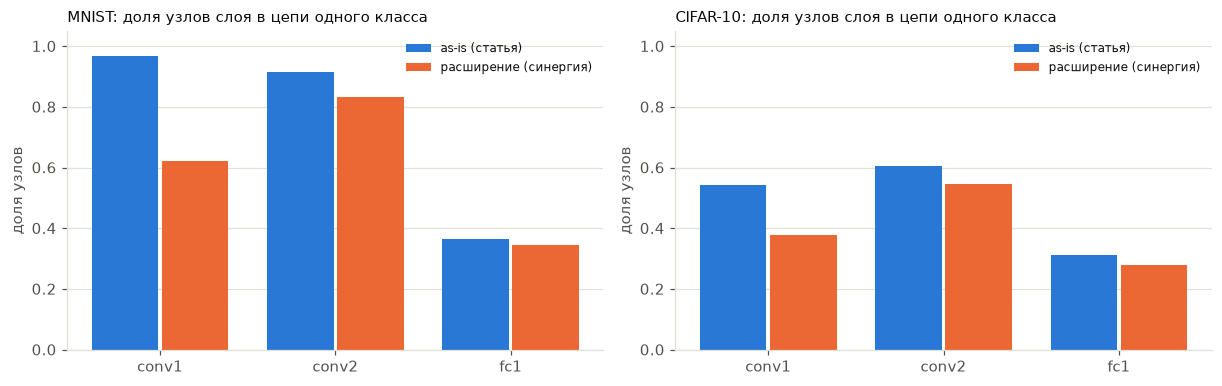

In [9]:
# 6.1 Насыщение критерия значимости: какая доля проверенных узлов критична и какая доля узлов остаётся в цепи класса
sat = (diag.assign(asis_critical_share=diag.asis_critical / diag.n_nodes, ext_critical_share=diag.ext_critical / diag.n_nodes, harmful_share=diag.ext_harmful / diag.n_nodes,
                   asis_chosen_share=diag.chosen_asis / diag.n_nodes, ext_chosen_share=diag.chosen_ext / diag.n_nodes)
       .groupby(['dataset', 'parent'])[['asis_critical_share', 'ext_critical_share', 'harmful_share', 'asis_chosen_share', 'ext_chosen_share']].mean().reindex(PARENTS, level=1))
print('Доля узлов слоя (среднее по классам и сетям): критичны по as-is / по расширению (BY+tau); вредны; остаются в цепи класса (as-is / расширение):')
display(sat.round(3))
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.6 * len(DATASETS), 3.6), squeeze=False)
for ax, ds in zip(axes[0], DATASETS):
    s = sat.loc[ds]; x = np.arange(3)
    ax.bar(x - 0.2, s.asis_chosen_share, 0.38, color=COL['as-is (статья)'], label='as-is (статья)', linewidth=0)
    ax.bar(x + 0.2, s.ext_chosen_share, 0.38, color=COL['расширение (синергия)'], label='расширение (синергия)', linewidth=0)
    ax.set_xticks(x); ax.set_xticklabels(PARENTS); ax.set_ylim(0, 1.05); style(ax, f'{ds}: доля узлов слоя в цепи одного класса', '', 'доля узлов'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### 6.2 Что делает правило внутри одного класса

Сколько узлов добавляет правило (пары $S>0$, узлы не были `critical`), сколько удаляет (пары $S<0$, проигравший по вкладу в логит) и сколько узлов попало в оба списка (добавлен по $S>0$ и удалён по $S<0$, то есть удаление победило). `harm_in_added` - сколько из добавленных узлов по одиночному TE `harmful` (ограничение 2).

Правило на слоях с нелинейностью (`fc1 -> fc2`: S = 0 по построению, правило = as-is с BY и tau). Среднее на один класс и слой, по 5 сетям:


n_pairs  n_syn  n_sub  nonadd_share  ext_critical  added  \
dataset  parent                                                             
CIFAR-10 conv1     120.0  30.68  30.98          0.51          8.36   7.38   
         conv2     496.0   2.84   4.32          0.01         18.58   1.52   
MNIST    conv1      15.0   3.66   4.02          0.51          5.78   0.18   
         conv2      45.0   0.60   1.06          0.04          9.10   0.06   

                 removed  conflict  harm_in_added  chosen_asis  chosen_ext  \
dataset  parent                                                              
CIFAR-10 conv1      9.68      9.58           5.10         8.68        6.06   
         conv2      2.60      0.86           1.32        19.38       17.50   
MNIST    conv1      2.22      1.92           0.14         5.80        3.74   
         conv2      0.84      0.20           0.02         9.14        8.32   

                 jaccard  
dataset  parent           
CIFAR-10 conv1      0.32  
         conv2      0.79  
MNIST    conv1      0.65  
         conv2      0.90

Сумма по всем классам и сетям:


,added,removed,conflict,harm_in_added,доля harmful среди добавленных
dataset,,,,,
CIFAR-10,445,614,522,321,0.721348
MNIST,12,153,106,8,0.666667


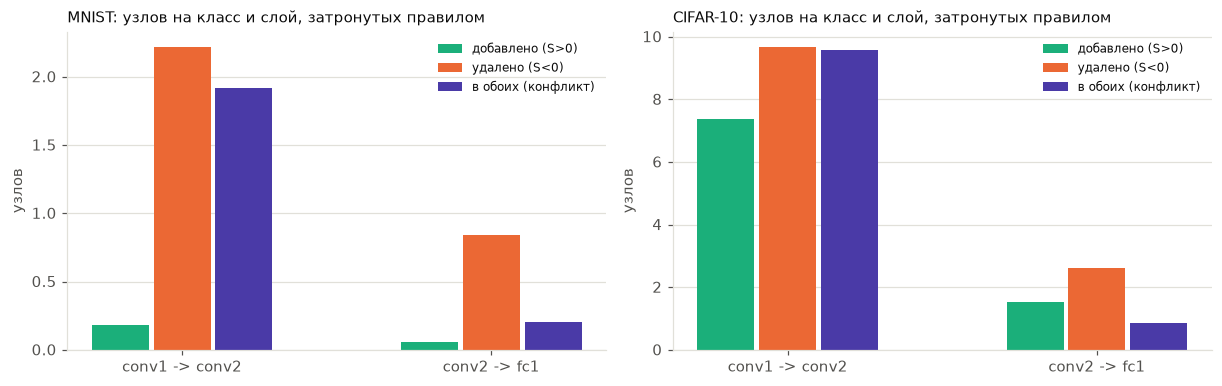

In [10]:
# 6.2 Что делает правило по классам: сколько узлов добавлено (S>0), удалено (S<0), попало в оба (конфликт)
r = diag[diag.parent != 'fc1'].copy(); r['nonadd_share'] = (r.n_syn + r.n_sub) / r.n_pairs
g = (r.groupby(['dataset', 'parent'])[['n_pairs', 'n_syn', 'n_sub', 'nonadd_share', 'ext_critical', 'added', 'removed', 'conflict', 'harm_in_added', 'chosen_asis', 'chosen_ext', 'jaccard']].mean().reindex(PARENTS[:2], level=1))
print('Правило на слоях с нелинейностью (`fc1 -> fc2`: S = 0 по построению, правило = as-is с BY и tau). Среднее на один класс и слой, по 5 сетям:')
display(g.round(2))
tot = r.groupby('dataset')[['added', 'removed', 'conflict', 'harm_in_added']].sum()
tot['доля harmful среди добавленных'] = tot.harm_in_added / tot.added.replace(0, np.nan)
print('Сумма по всем классам и сетям:'); display(tot)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.6 * len(DATASETS), 3.6), squeeze=False)
for ax, ds in zip(axes[0], DATASETS):
    s = g.loc[ds]; x = np.arange(2); w = 0.2
    for i, (col, lab, c) in enumerate([('added', 'добавлено (S>0)', '#1baf7a'), ('removed', 'удалено (S<0)', '#eb6834'), ('conflict', 'в обоих (конфликт)', '#4a3aa7')]):
        ax.bar(x + (i - 1) * w, s[col], w * 0.92, color=c, label=lab, linewidth=0)
    ax.set_xticks(x); ax.set_xticklabels(['conv1 -> conv2', 'conv2 -> fc1']); style(ax, f'{ds}: узлов на класс и слой, затронутых правилом', '', 'узлов'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### 6.3 Объединение по классам, возврат узлов и размер

Прунинг сети целиком берёт объединение цепей по классам. Здесь видно, сколько удалений правила «отменяется» другими классами, чем в итоге отличается расширение от as-is по числу узлов и сколько весов даёт узловая подматрица по сравнению с объединением путей (маска v2).

In [11]:
# 6.3 Объединение по классам: возврат удалённых узлов, размеры, доля весов (узлы против путей v2)
back = reentry[reentry.parent != 'fc1'].groupby(['dataset', 'parent'])[['removed', 'reentered']].sum().reindex(PARENTS[:2], level=1)
back['доля вернувшихся'] = back.reentered / back.removed.replace(0, np.nan)
print('Узлы, удалённые правилом из цепи класса k (S<0), и доля тех, которые вернулись через цепь другого класса (по 5 сетям, все классы):')
display(back.round(3))
u = union.groupby(['dataset', 'parent'])[['n_nodes', 'asis', 'ext', 'ext_minus_asis', 'asis_minus_ext']].mean().reindex(PARENTS, level=1)
print('\nРазмер объединения по классам (среднее по 5 сетям), узлов; ext_minus_asis = узлы, спасённые расширением, asis_minus_ext = отброшенные:')
display(u.round(2))
print('\nДоля весов сети: подматрица оставленных узлов (используется здесь) против объединения путей, проверенных интервенциями (маска v2). Среднее по 5 сетям:')
display(shares.groupby('dataset')[['node_share_asis', 'node_share_ext', 'path_share_asis', 'path_share_ext']].mean().round(4))

Узлы, удалённые правилом из цепи класса k (S<0), и доля тех, которые вернулись через цепь другого класса (по 5 сетям, все классы):


removed  reentered  доля вернувшихся
dataset  parent                                      
CIFAR-10 conv1       484        484               1.0
         conv2       130        130               1.0
MNIST    conv1       111        111               1.0
         conv2        42         42               1.0


Размер объединения по классам (среднее по 5 сетям), узлов; ext_minus_asis = узлы, спасённые расширением, asis_minus_ext = отброшенные:


n_nodes  asis   ext  ext_minus_asis  asis_minus_ext
dataset  parent                                                     
CIFAR-10 conv1      16.0  15.2  16.0             0.8             0.0
         conv2      32.0  30.4  30.4             0.0             0.0
         fc1        64.0  42.0  42.0             0.0             0.0
MNIST    conv1       6.0   6.0   6.0             0.0             0.0
         conv2      10.0   9.6   9.6             0.0             0.0
         fc1        24.0  16.4  16.4             0.0             0.0


Доля весов сети: подматрица оставленных узлов (используется здесь) против объединения путей, проверенных интервенциями (маска v2). Среднее по 5 сетям:


,node_share_asis,node_share_ext,path_share_asis,path_share_ext
dataset,,,,
CIFAR-10,0.6839,0.6940,0.6578,0.6409
MNIST,0.7445,0.7445,0.7311,0.7292


### 6.4 Сравнение методов при равном размере

Строки таблиц идут в порядке: сначала метод-референс (as-is на размере `A`, расширение на `E`, `расширение (ATE+синергия)` на `S70` и `S40`), затем контроли размера, случайный, магнитуда, greedy, обучение с нуля. В КАЖДОЙ из четырёх таблиц есть строка с синергией: на `A`, `S70`, `S40` это `расширение (ATE+синергия)` - то же правило синергии, но обобщённое на заданный размер (раздел 4), а не только на свой естественный. `agree` - доля тестовых изображений, где предсказание совпадает с предсказанием исходной сети. Запас $H$ показывает, есть ли вообще что различать на данном размере.

In [12]:
# 6.4 Сравнение методов при равном размере. Случайные линии усреднены по розыгрышам внутри сети; затем среднее ± std по 5 сетям.
MET = ['acc', 'macro_recall', 'min_recall', 'agree', 'w_share', 'mac_share', 'ft_acc', 'ft_macro_recall', 'ft_min_recall']
per_seed = rows.groupby(['dataset', 'seed', 'tag', 'method'])[MET].mean().reset_index()
REF = {'A': 'as-is (статья)', 'E': 'расширение (синергия)', 'S70': 'расширение (ATE+синергия)', 'S40': 'расширение (ATE+синергия)'}
ORDER = {'A': ['as-is (статья)', 'расширение (ATE+синергия)', 'случайный (узлы)', 'магнитуда (узлы)', 'greedy backward'],
         'E': ['расширение (синергия)', 'as-is + случайное дополнение', 'as-is + топ-ATE дополнение', 'случайный (узлы)', 'магнитуда (узлы)', 'greedy backward', 'с нуля (та же форма)'],
         'S70': ['as-is (топ-ATE)', 'расширение (ATE+синергия)', 'случайный (узлы)', 'магнитуда (узлы)', 'greedy backward', 'с нуля (та же форма)'],
         'S40': ['as-is (топ-ATE)', 'расширение (ATE+синергия)', 'случайный (узлы)', 'магнитуда (узлы)', 'greedy backward', 'с нуля (та же форма)']}
TAG_TITLE = {'A': 'размер as-is', 'E': 'размер расширения', 'S70': '70% узлов в каждом слое', 'S40': '40% узлов в каждом слое'}

def tag_table(ds, tag):
    d = per_seed[(per_seed.dataset == ds) & (per_seed.tag == tag)]; ref = REF[tag]; ref_acc = d[d.method == ref].set_index('seed').acc
    out = []
    for m in ORDER[tag]:
        x = d[d.method == m]
        if not len(x): continue
        delta = (ref_acc - x.set_index('seed').acc) if m != ref else None
        out.append({'метод': m, 'доля весов': fmt(x.w_share.mean(), x.w_share.std(), 3), 'acc без дообучения': fmt(x.acc.mean(), x.acc.std()), 'macro-recall': fmt(x.macro_recall.mean(), x.macro_recall.std()),
                    'мин. recall': fmt(x.min_recall.mean(), x.min_recall.std()), 'agree': fmt(x.agree.mean(), x.agree.std()), 'acc с дообучением': fmt(x.ft_acc.mean(), x.ft_acc.std()) if x.ft_acc.notna().any() else '-',
                    f'Δacc: {ref.split(" (")[0]} минус метод': '-' if delta is None else f'{delta.mean():+.4f} (побед {int((delta > 0).sum())}/{len(delta)})'})
    return pd.DataFrame(out).set_index('метод')

def headroom(ds, tag):
    d = per_seed[(per_seed.dataset == ds) & (per_seed.tag == tag)]; o = orig[orig.dataset == ds].set_index('seed').acc
    r = d[d.method == 'случайный (узлы)'].set_index('seed').acc; return float((o - r).mean()), float((o - r).std())

for tag in ['A', 'E', 'S70', 'S40']:
    for ds in DATASETS:
        h = headroom(ds, tag)
        print(f'\n=== {ds}, {TAG_TITLE[tag]}. Запас H = acc(исходная) - acc(случайная того же размера) = {h[0]:.3f} ± {h[1]:.3f} ===')
        display(tag_table(ds, tag))


=== MNIST, размер as-is. Запас H = acc(исходная) - acc(случайная того же размера) = 0.390 ± 0.152 ===


,доля весов,acc без дообучения,macro-recall,мин. recall,agree,acc с дообучением,Δacc: as-is минус метод
метод,,,,,,,
as-is (статья),0.745 ± 0.075,0.9449 ± 0.0061,0.9445 ± 0.0063,0.8949 ± 0.0250,1.0000 ± 0.0000,-,-
расширение (ATE+синергия),0.745 ± 0.075,0.9449 ± 0.0061,0.9445 ± 0.0063,0.8949 ± 0.0250,1.0000 ± 0.0000,-,+0.0000 (побед 0/5)
случайный (узлы),0.745 ± 0.075,0.5546 ± 0.1570,0.5524 ± 0.1583,0.0756 ± 0.1075,0.5619 ± 0.1592,-,+0.3903 (побед 5/5)
магнитуда (узлы),0.745 ± 0.075,0.9449 ± 0.0061,0.9445 ± 0.0063,0.8949 ± 0.0250,1.0000 ± 0.0000,-,+0.0000 (побед 0/5)
greedy backward,0.745 ± 0.075,0.9449 ± 0.0061,0.9445 ± 0.0063,0.8949 ± 0.0250,1.0000 ± 0.0000,-,+0.0000 (побед 0/5)



=== CIFAR-10, размер as-is. Запас H = acc(исходная) - acc(случайная того же размера) = 0.185 ± 0.043 ===


,доля весов,acc без дообучения,macro-recall,мин. recall,agree,acc с дообучением,Δacc: as-is минус метод
метод,,,,,,,
as-is (статья),0.684 ± 0.040,0.6454 ± 0.0258,0.6454 ± 0.0258,0.4370 ± 0.0559,0.8878 ± 0.0710,-,-
расширение (ATE+синергия),0.684 ± 0.040,0.6454 ± 0.0258,0.6454 ± 0.0258,0.4370 ± 0.0559,0.8878 ± 0.0710,-,+0.0000 (побед 0/5)
случайный (узлы),0.684 ± 0.040,0.4846 ± 0.0437,0.4846 ± 0.0437,0.1293 ± 0.0540,0.5723 ± 0.0577,-,+0.1608 (побед 5/5)
магнитуда (узлы),0.684 ± 0.040,0.6519 ± 0.0170,0.6519 ± 0.0170,0.4222 ± 0.0295,0.8900 ± 0.0699,-,-0.0065 (побед 1/5)
greedy backward,0.685 ± 0.040,0.6644 ± 0.0053,0.6644 ± 0.0053,0.4566 ± 0.0206,0.9115 ± 0.0402,-,-0.0190 (побед 1/5)



=== MNIST, размер расширения. Запас H = acc(исходная) - acc(случайная того же размера) = 0.406 ± 0.164 ===


...

,доля весов,acc без дообучения,macro-recall,мин. recall,agree,acc с дообучением,Δacc: расширение минус метод
метод,,,,,,,
as-is (топ-ATE),0.487 ± 0.000,0.3708 ± 0.0665,0.3708 ± 0.0665,0.0184 ± 0.0130,0.4186 ± 0.0752,0.6577 ± 0.0064,+0.0226 (побед 1/5)
расширение (ATE+синергия),0.487 ± 0.000,0.3934 ± 0.0601,0.3934 ± 0.0601,0.0396 ± 0.0420,0.4463 ± 0.0710,0.6578 ± 0.0063,-
случайный (узлы),0.487 ± 0.000,0.2813 ± 0.0116,0.2813 ± 0.0116,0.0132 ± 0.0075,0.3118 ± 0.0155,0.6417 ± 0.0077,+0.1121 (побед 5/5)
магнитуда (узлы),0.487 ± 0.000,0.4202 ± 0.0521,0.4202 ± 0.0521,0.0958 ± 0.0923,0.4799 ± 0.0593,0.6610 ± 0.0048,-0.0268 (побед 1/5)
greedy backward,0.487 ± 0.003,0.6230 ± 0.0113,0.6230 ± 0.0113,0.3850 ± 0.0599,0.7619 ± 0.0212,0.6758 ± 0.0061,-0.2296 (побед 0/5)
с нуля (та же форма),0.487 ± 0.000,0.6554 ± 0.0118,0.6554 ± 0.0118,0.4250 ± 0.0580,0.6896 ± 0.0073,-,-0.2620 (побед 0/5)



=== MNIST, 40% узлов в каждом слое. Запас H = acc(исходная) - acc(случайная того же размера) = 0.719 ± 0.033 ===


,доля весов,acc без дообучения,macro-recall,мин. recall,agree,acc с дообучением,Δacc: расширение минус метод
метод,,,,,,,
as-is (топ-ATE),0.173 ± 0.000,0.3796 ± 0.2155,0.3797 ± 0.2154,0.0606 ± 0.1354,0.3807 ± 0.2211,0.8827 ± 0.0244,+0.0083 (побед 1/5)
расширение (ATE+синергия),0.173 ± 0.000,0.3880 ± 0.2142,0.3874 ± 0.2142,0.0606 ± 0.1354,0.3889 ± 0.2197,0.8825 ± 0.0247,-
случайный (узлы),0.173 ± 0.000,0.2259 ± 0.0324,0.2256 ± 0.0326,0.0001 ± 0.0001,0.2280 ± 0.0322,0.8310 ± 0.0360,+0.1621 (побед 4/5)
магнитуда (узлы),0.173 ± 0.000,0.3315 ± 0.1202,0.3274 ± 0.1200,0.0000 ± 0.0000,0.3348 ± 0.1224,0.9041 ± 0.0168,+0.0564 (побед 3/5)
greedy backward,0.171 ± 0.007,0.5779 ± 0.0835,0.5817 ± 0.0812,0.0704 ± 0.1569,0.5812 ± 0.0832,0.8858 ± 0.0244,-0.1899 (побед 0/5)
с нуля (та же форма),0.173 ± 0.000,0.9093 ± 0.0054,0.9082 ± 0.0054,0.8298 ± 0.0188,0.9266 ± 0.0073,-,-0.5213 (побед 0/5)



=== CIFAR-10, 40% узлов в каждом слое. Запас H = acc(исходная) - acc(случайная того же размера) = 0.517 ± 0.014 ===


,доля весов,acc без дообучения,macro-recall,мин. recall,agree,acc с дообучением,Δacc: расширение минус метод
метод,,,,,,,
as-is (топ-ATE),0.169 ± 0.000,0.1518 ± 0.0456,0.1518 ± 0.0456,0.0000 ± 0.0000,0.1605 ± 0.0473,0.5765 ± 0.0125,+0.0104 (побед 3/5)
расширение (ATE+синергия),0.169 ± 0.000,0.1622 ± 0.0455,0.1622 ± 0.0455,0.0000 ± 0.0000,0.1754 ± 0.0479,0.5752 ± 0.0109,-
случайный (узлы),0.169 ± 0.000,0.1527 ± 0.0100,0.1527 ± 0.0100,0.0003 ± 0.0006,0.1587 ± 0.0092,0.5456 ± 0.0115,+0.0095 (побед 3/5)
магнитуда (узлы),0.169 ± 0.000,0.1776 ± 0.0468,0.1776 ± 0.0468,0.0000 ± 0.0000,0.1892 ± 0.0556,0.5843 ± 0.0061,-0.0154 (побед 2/5)
greedy backward,0.167 ± 0.002,0.4315 ± 0.0097,0.4315 ± 0.0097,0.1600 ± 0.0730,0.4780 ± 0.0097,0.6216 ± 0.0087,-0.2693 (побед 0/5)
с нуля (та же форма),0.169 ± 0.000,0.5937 ± 0.0090,0.5937 ± 0.0090,0.3334 ± 0.0888,0.6454 ± 0.0091,-,-0.4315 (побед 0/5)


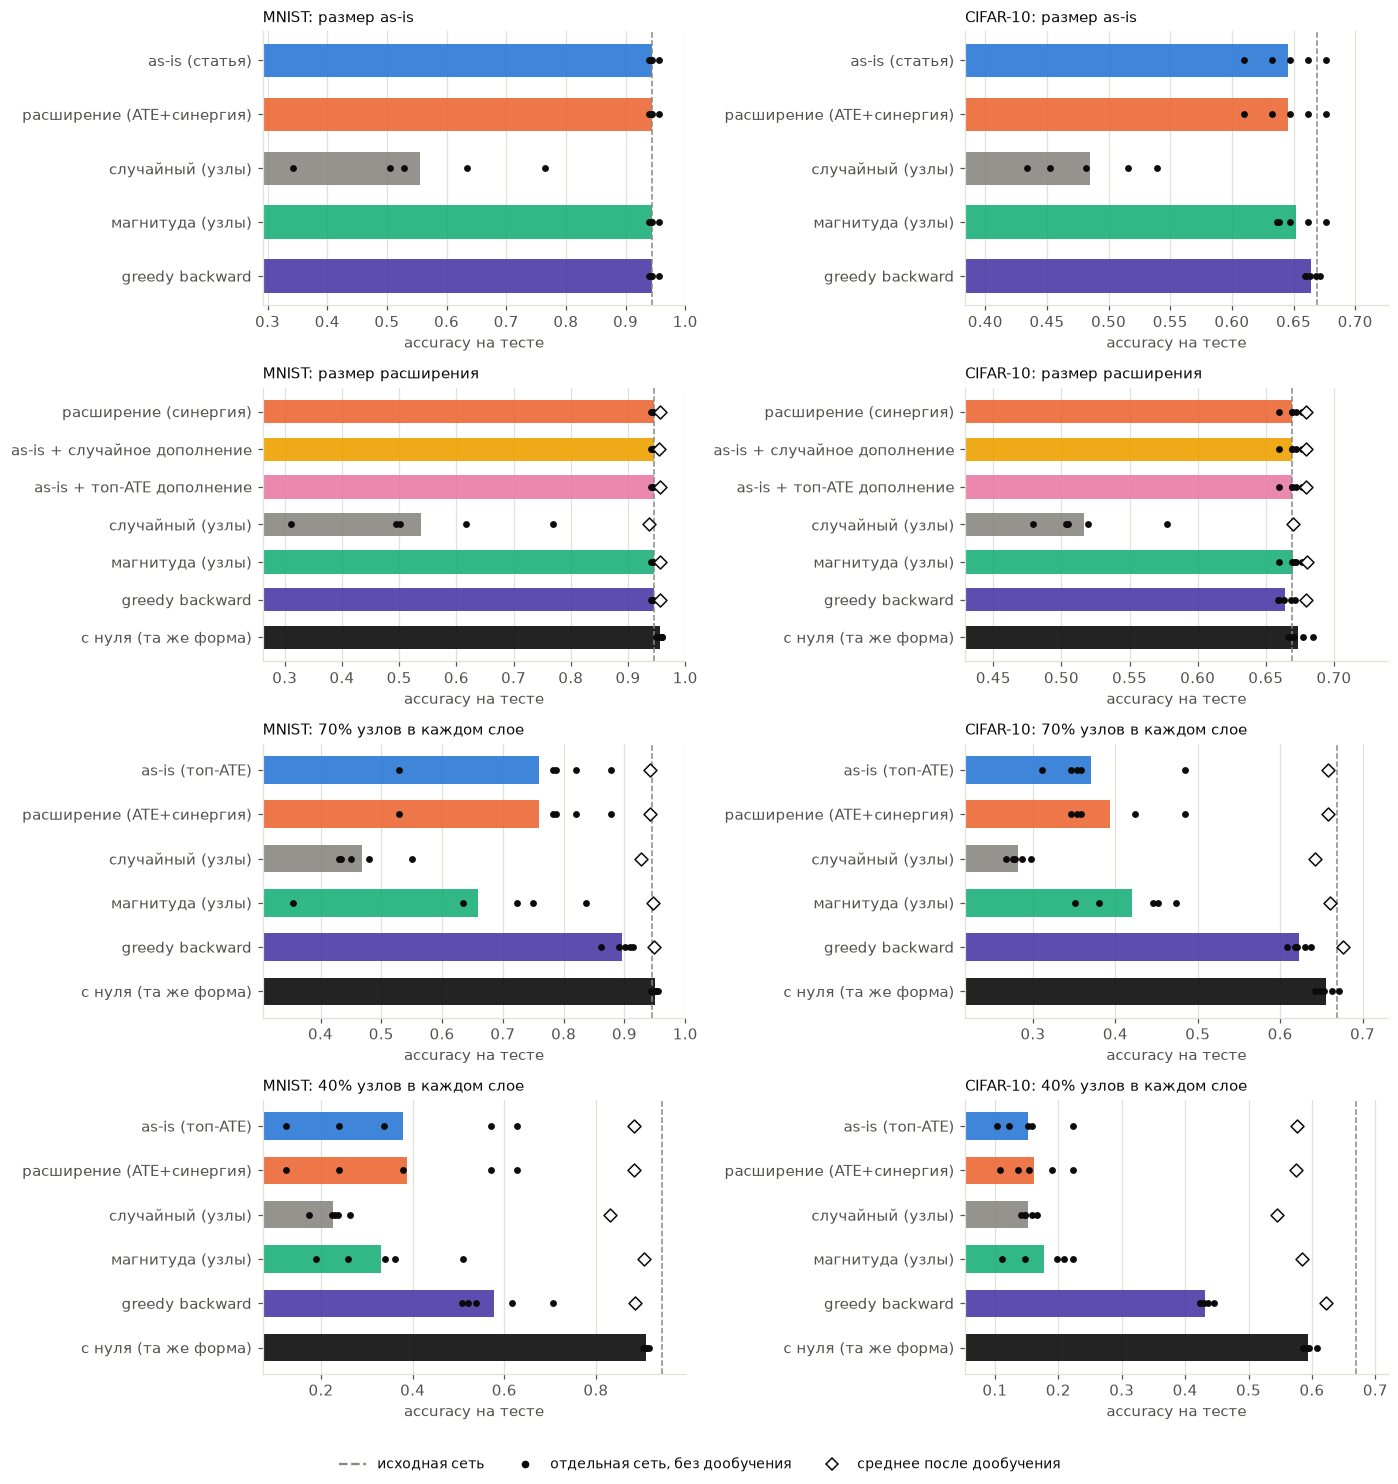

In [13]:
# Графики сравнения при равном размере: столбец - точность без дообучения (среднее по сетям), точки - отдельные сети, ромб - после дообучения
fig, axes = plt.subplots(4, len(DATASETS), figsize=(6.4 * len(DATASETS), 13.5), squeeze=False)
for i, tag in enumerate(['A', 'E', 'S70', 'S40']):
    for j, ds in enumerate(DATASETS):
        ax = axes[i, j]; d = per_seed[(per_seed.dataset == ds) & (per_seed.tag == tag)]; ms = [m for m in ORDER[tag] if (d.method == m).any()]
        for k, m in enumerate(ms):
            x = d[d.method == m]; ax.barh(k, x.acc.mean(), 0.62, color=COL[m], linewidth=0, alpha=0.9)
            ax.scatter(x.acc, np.full(len(x), k), s=12, color=INK, zorder=3)
            if x.ft_acc.notna().any(): ax.scatter(x.ft_acc.mean(), k, marker='D', s=36, color='white', edgecolor=INK, zorder=4)
        ax.axvline(orig[orig.dataset == ds].acc.mean(), color=MUT, ls='--', lw=1)
        ax.set_yticks(range(len(ms))); ax.set_yticklabels(ms); ax.invert_yaxis(); ax.set_xlim(max(0, d.acc.min() - 0.05), min(1.0, max(d.acc.max(), d.ft_acc.max(skipna=True) if d.ft_acc.notna().any() else 0, orig[orig.dataset == ds].acc.mean()) + 0.05))
        style(ax, f'{ds}: {TAG_TITLE[tag]}', 'accuracy на тесте', '', grid='x')
h = [plt.Line2D([], [], color=MUT, ls='--', label='исходная сеть'), plt.Line2D([], [], marker='o', ls='', color=INK, ms=4, label='отдельная сеть, без дообучения'),
     plt.Line2D([], [], marker='D', ls='', color='white', mec=INK, ms=6, label='среднее после дообучения')]
fig.legend(handles=h, loc='lower center', ncol=3, frameon=False, fontsize=9); plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

Линия «расширение (ATE+синергия)» почти сливается с линией «as-is (топ-ATE)» - это не ошибка отрисовки: реальная разница между ними на большинстве долей весов действительно 1-2 процентных пункта (см. ячейку ниже, где эта разница показана отдельно, потому что на глаз две почти совпадающие линии её не показывают).


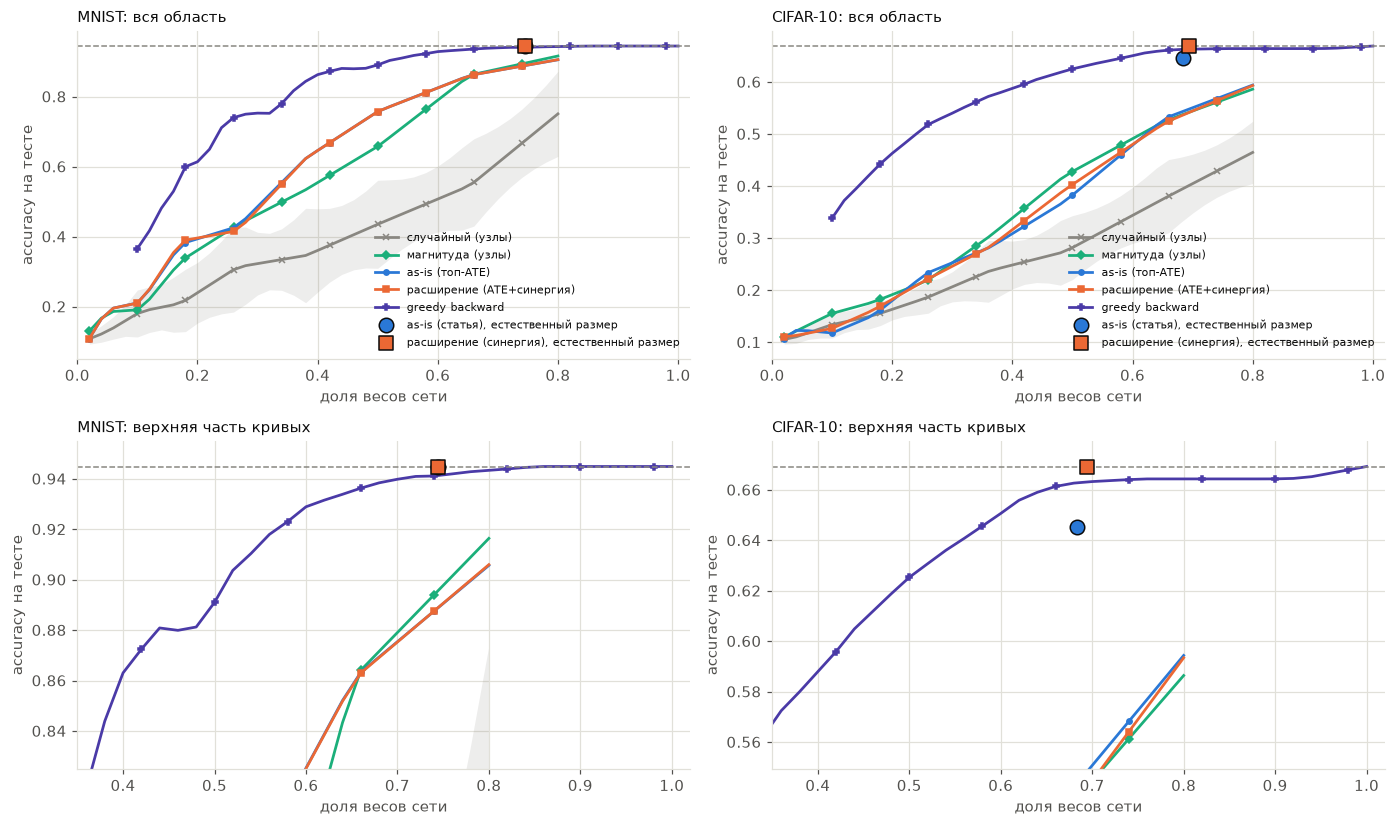

In [14]:
# 6.4b Зачем этот график. Каждая линия - один критерий отбора узлов, принудительно применённый к сетке долей весов
# (0.02, 0.1, 0.2, ..., 1.0), а не только к тому размеру, который метод выбрал бы сам. Это нужно, чтобы сравнить
# критерии «при прочих равных» на любом размере, а не только в двух точках (естественные размеры as-is и расширения).
# Крупные значки - естественный размер: сколько узлов сам метод оставляет, если его не заставлять попасть в конкретную долю.
# Они НЕ лежат на линии своего цвета - линия отвечает на другой вопрос («что было бы при доле X»), а значок - на свой
# («сколько метод оставил сам»).
print('Линия «расширение (ATE+синергия)» почти сливается с линией «as-is (топ-ATE)» - это не ошибка отрисовки: '
      'реальная разница между ними на большинстве долей весов действительно 1-2 процентных пункта (см. ячейку ниже, '
      'где эта разница показана отдельно, потому что на глаз две почти совпадающие линии её не показывают).')
fig, axes = plt.subplots(2, len(DATASETS), figsize=(6.4 * len(DATASETS), 7.6), squeeze=False)
for j, ds in enumerate(DATASETS):
    c = curves[curves.dataset == ds]; o = orig[orig.dataset == ds].acc.mean()
    for row_i, (xlo, ylo, ttl) in enumerate([(0, 0, 'вся область'), (0.35, None, 'верхняя часть кривых')]):
        ax = axes[row_i, j]
        for m in ['случайный (узлы)', 'магнитуда (узлы)', 'as-is (топ-ATE)', 'расширение (ATE+синергия)', 'greedy backward']:
            x = c[c.method == m]; grid = np.linspace(0.02, 1.0, 50)
            # у каждой сети (и розыгрыша) свои доли весов: интерполируем кривую на общую сетку и усредняем, иначе точки разных сетей не совпадают по оси x
            ys = np.array([np.interp(grid, g.sort_values('w_share').w_share.values, g.sort_values('w_share').acc.values, left=np.nan, right=np.nan) for _, g in x.groupby(['seed', 'draw'])])
            mean, sd = np.nanmean(ys, axis=0), np.nanstd(ys, axis=0); ok = ~np.isnan(mean)
            ax.plot(grid[ok], mean[ok], color=COL[m], lw=1.8, marker=MRK[m], ms=3.5, markevery=4, label=m)
            if m == 'случайный (узлы)': ax.fill_between(grid[ok], (mean - sd)[ok], (mean + sd)[ok], color=COL[m], alpha=0.15, linewidth=0)
        for tag, m, mk in [('A', 'as-is (статья)', 'o'), ('E', 'расширение (синергия)', 's')]:
            p = per_seed[(per_seed.dataset == ds) & (per_seed.tag == tag) & (per_seed.method == m)]
            ax.scatter(p.w_share.mean(), p.acc.mean(), s=90, marker=mk, color=COL[m], edgecolor=INK, zorder=5, label=f'{m}, естественный размер')
        ax.axhline(o, color=MUT, ls='--', lw=1); ax.set_xlim(xlo, 1.02)
        if ylo is None: ax.set_ylim(o - 0.12, o + 0.01)
        style(ax, f'{ds}: {ttl}', 'доля весов сети', 'accuracy на тесте', grid='both')
    axes[0, j].legend(frameon=False, fontsize=7.5, loc='lower right')
plt.tight_layout(); plt.show()

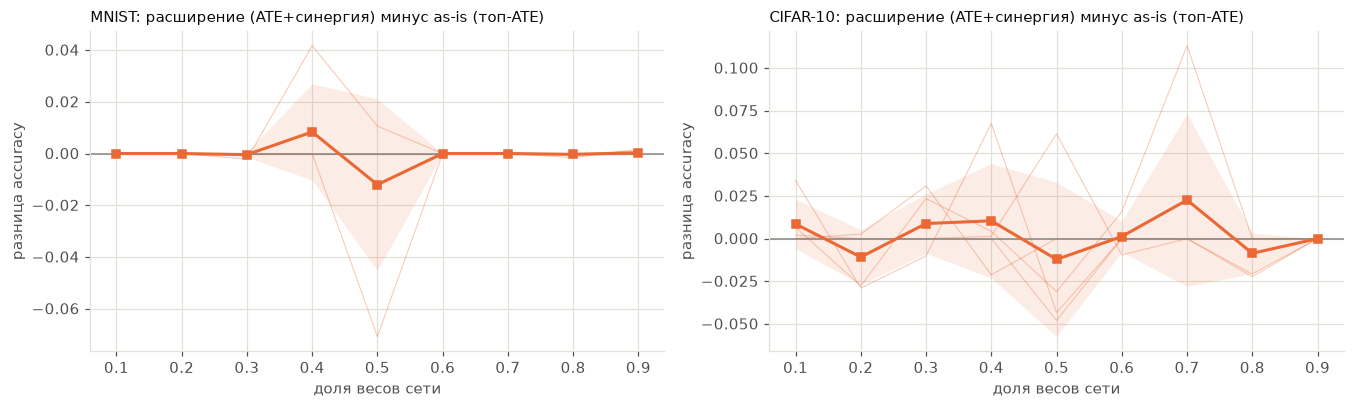

Среднее в каждой точке - та же величина, что столбец Δacc в таблицах 6.4 на долях 0.7 и 0.4 (раздел 4), здесь она показана на всей сетке долей. Разброс между отдельными сетями (тонкие линии, область ± std) на большинстве долей того же порядка, что и само среднее: устойчивого преимущества синергии над топ-ATE без учёта S не видно ни на одной доле весов.


In [15]:
# 6.4c Разница между «расширение (ATE+синергия)» и «as-is (топ-ATE)» по всей сетке долей весов (не только на 0.7 и 0.4, как в таблицах 6.4).
# Положительное значение - синергия точнее; отрицательное - топ-ATE точнее. Тонкие линии - отдельные сети (5 на точку), толстая - среднее.
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.2 * len(DATASETS), 3.8), squeeze=False)
for ax, ds in zip(axes[0], DATASETS):
    c = curves[curves.dataset == ds]
    piv = c[c.method.isin(['as-is (топ-ATE)', 'расширение (ATE+синергия)'])].groupby(['seed', 'frac', 'method']).acc.mean().unstack('method')
    d = piv['расширение (ATE+синергия)'] - piv['as-is (топ-ATE)']
    for seed_, sub in d.groupby(level='seed'):
        sub = sub.sort_index(level='frac'); ax.plot(sub.index.get_level_values('frac'), sub.values, color=COL['расширение (ATE+синергия)'], lw=0.7, alpha=0.35)
    g = d.groupby(level='frac').agg(['mean', 'std'])
    ax.plot(g.index, g['mean'], color=COL['расширение (ATE+синергия)'], marker='s', ms=5, lw=2, zorder=5)
    ax.fill_between(g.index, g['mean'] - g['std'], g['mean'] + g['std'], color=COL['расширение (ATE+синергия)'], alpha=0.12, linewidth=0)
    ax.axhline(0, color=MUT, lw=1)
    style(ax, f'{ds}: расширение (ATE+синергия) минус as-is (топ-ATE)', 'доля весов сети', 'разница accuracy', grid='both')
plt.tight_layout(); plt.show()
print('Среднее в каждой точке - та же величина, что столбец Δacc в таблицах 6.4 на долях 0.7 и 0.4 (раздел 4), здесь она '
      'показана на всей сетке долей. Разброс между отдельными сетями (тонкие линии, область ± std) на большинстве долей '
      'того же порядка, что и само среднее: устойчивого преимущества синергии над топ-ATE без учёта S не видно ни на одной доле весов.')

### 6.5-6.6 Стоимость

Отбор: число прямых проходов по изображениям (не зависит от машины) и секунды на этом CPU. Сеть: параметры, MAC и измеренное время прямого прохода компактной сети (1 поток, чтобы измерять вычисления, а не накладные расходы на потоки; на таких малых сетях время может определяться накладными расходами вызова, а не MAC).

Стоимость отбора для сети целиком (10 классов для as-is и расширения; greedy - один проход). Среднее по 5 сетям:


images         seconds      
                                     mean     std    mean   std
dataset  method                                                
CIFAR-10 as-is (статья)          144640.0     0.0    20.6   1.8
         расширение (синергия)   933120.0     0.0   134.1   4.1
         greedy backward        3495360.0  8586.5   439.8  17.7
         магнитуда (узлы)             0.0     0.0     0.0   0.0
         случайный (узлы)             0.0     0.0     0.0   0.0
MNIST    as-is (статья)           52480.0     0.0     2.2   0.2
         расширение (синергия)   129280.0     0.0     5.1   0.3
         greedy backward         760600.0  6024.9    18.3   0.3
         магнитуда (узлы)             0.0     0.0     0.0   0.0
         случайный (узлы)             0.0     0.0     0.0   0.0


Отношение стоимости: greedy / расширение и расширение / as-is (по прямым проходам; среднее по сетям):


,greedy / расширение,расширение / as-is,"greedy / расширение, секунды"
dataset,,,
CIFAR-10,3.75,6.45,3.28
MNIST,5.88,2.46,3.57



Прореженная сеть как плотная сеть меньшей ширины: параметры, MAC и измеренное время прямого прохода (1 поток, медиана, мс). Среднее по 5 сетям:


params       macs  ms_batch1  ms_batch256
dataset  net                                                              
CIFAR-10 40% узлов              11165.0   556510.0      0.514       36.550
         исходная сеть          65962.0  2272640.0      0.827       87.940
         расширение (размер E)  45793.4  2189135.0      0.762       86.032
MNIST    40% узлов               1016.0    42340.0      0.243        5.257
         исходная сеть           5780.0   186480.0      0.394       12.315
         расширение (размер E)   4308.0   181236.0      0.261       11.539

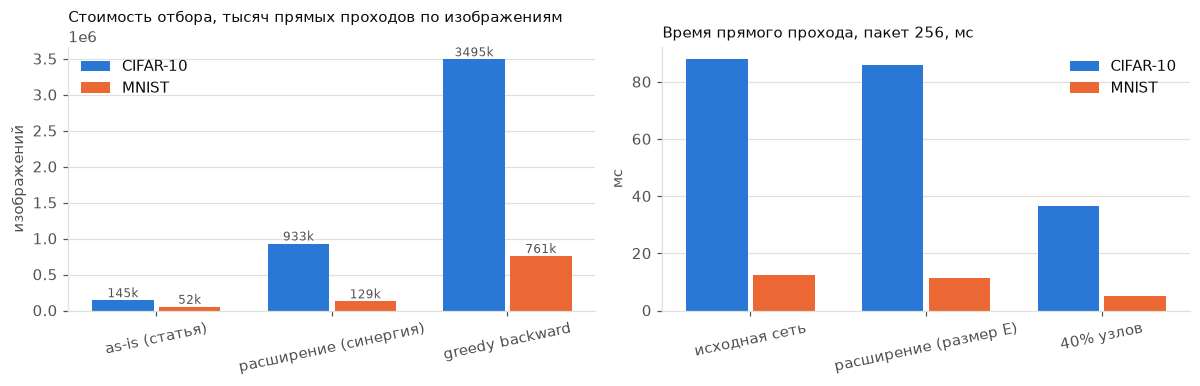

In [16]:
# 6.5 Стоимость отбора (прямые проходы по изображениям - аппаратно-независимая мера - и секунды на этом CPU) и 6.6 стоимость работы прореженной сети
cs = cost.groupby(['dataset', 'method'])[['images', 'seconds']].agg(['mean', 'std'])
print('Стоимость отбора для сети целиком (10 классов для as-is и расширения; greedy - один проход). Среднее по 5 сетям:')
display(cs.round(1).reindex([m for m in ['as-is (статья)', 'расширение (синергия)', 'greedy backward', 'магнитуда (узлы)', 'случайный (узлы)']], level=1))
rat = cost.pivot_table(index=['dataset', 'seed'], columns='method', values=['images', 'seconds'])
print('\nОтношение стоимости: greedy / расширение и расширение / as-is (по прямым проходам; среднее по сетям):')
display(pd.DataFrame({'greedy / расширение': (rat['images']['greedy backward'] / rat['images']['расширение (синергия)']).groupby('dataset').mean(),
                      'расширение / as-is': (rat['images']['расширение (синергия)'] / rat['images']['as-is (статья)']).groupby('dataset').mean(),
                      'greedy / расширение, секунды': (rat['seconds']['greedy backward'] / rat['seconds']['расширение (синергия)']).groupby('dataset').mean()}).round(2))
lt = latency.groupby(['dataset', 'net'])[['params', 'macs', 'ms_batch1', 'ms_batch256']].mean().round(3)
print('\nПрореженная сеть как плотная сеть меньшей ширины: параметры, MAC и измеренное время прямого прохода (1 поток, медиана, мс). Среднее по 5 сетям:')
display(lt)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
cm = cost[cost.method.isin(['as-is (статья)', 'расширение (синергия)', 'greedy backward'])].groupby(['dataset', 'method']).images.mean().unstack(0)
cm = cm.reindex(['as-is (статья)', 'расширение (синергия)', 'greedy backward']); x = np.arange(len(cm)); w = 0.38
for i, ds in enumerate(cm.columns): axes[0].bar(x + (i - 0.5) * w, cm[ds], w * 0.92, color=['#2a78d6', '#eb6834'][i], label=ds, linewidth=0)
for i, ds in enumerate(cm.columns):
    for xi, v in enumerate(cm[ds]): axes[0].text(xi + (i - 0.5) * w, v, f'{v / 1000:.0f}k', ha='center', va='bottom', fontsize=8, color=SEC)
axes[0].set_xticks(x); axes[0].set_xticklabels(cm.index, rotation=12); style(axes[0], 'Стоимость отбора, тысяч прямых проходов по изображениям', '', 'изображений'); axes[0].legend(frameon=False, loc='upper left')
lm = latency.groupby(['dataset', 'net']).ms_batch256.mean().unstack(0).reindex(['исходная сеть', 'расширение (размер E)', '40% узлов'])
for i, ds in enumerate(lm.columns): axes[1].bar(np.arange(len(lm)) + (i - 0.5) * w, lm[ds], w * 0.92, color=['#2a78d6', '#eb6834'][i], label=ds, linewidth=0)
axes[1].set_xticks(range(len(lm))); axes[1].set_xticklabels(lm.index, rotation=12); style(axes[1], 'Время прямого прохода, пакет 256, мс', '', 'мс'); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

### 6.7 Контроль на необученной сети

Зачем этот раздел: сам по себе флаг «пара значимо синергична» ничего не доказывает - он может появляться и в сети со случайными весами, просто из-за ReLU и max-pool, без всякого обучения. Проверка: одно и то же правило запускается на сети со случайными начальными весами (обучения не было вовсе), и число найденных синергичных/субаддитивных пар сравнивается с обученной сетью. Если числа сопоставимы, значит присутствие таких пар само по себе не говорит о выученной структуре, и правило нужно оценивать по метрикам прореженной сети, а не по числу найденных пар (ограничение 4).

In [17]:
# 6.7 Контроль: то же правило на необученной сети (случайные начальные веса, обучения нет). Зачем: если в необученной
# сети правило находит столько же "синергичных" и "субаддитивных" пар, сколько в обученной, значит флаг S != 0 сам по
# себе не говорит о том, что сеть ЧЕМУ-ТО НАУЧИЛАСЬ - он может быть свойством архитектуры (ReLU, max-pool), а не обучения.
# Примеры класса берутся без условия правильной классификации (у необученной сети такого множества почти нет).
def untrained_control(data, n_nets):
    out = []
    for s in range(n_nets):
        net = new_net(data, seed=1000 + s).eval()
        asis, _ = infer_all(net, data, PAPER_ASIS, require_correct=False); ext, _ = infer_all(net, data, EXT, require_correct=False)
        drows, _ = diag_rows(data, 1000 + s, asis, ext); out += drows
    return pd.DataFrame(out)
def untrained_cached(ds):
    p = CACHE_DIR / f'untrained_{ds}.pkl'
    if USE_CACHE and p.exists(): return pickle.load(open(p, 'rb'))
    out = untrained_control(Data(ds), 3 if ds == 'MNIST' else 2); pickle.dump(out, open(p, 'wb')); return out
UNTR = pd.concat([untrained_cached(ds).assign(сеть='необученная') for ds in DATASETS], ignore_index=True)
TR = diag.assign(сеть='обученная')
both = pd.concat([TR, UNTR], ignore_index=True); both = both[both.parent != 'fc1'].copy(); both['nonadd_share'] = (both.n_syn + both.n_sub) / both.n_pairs
both['critical_share'] = both.asis_critical / both.n_nodes
COLS7 = {'critical_share': 'доля критичных узлов (as-is)', 'nonadd_share': 'доля неаддитивных пар (синергичных + субаддитивных)',
         'n_syn': 'синергичных пар, шт. (на класс)', 'n_sub': 'субаддитивных пар, шт. (на класс)',
         'added': 'узлов добавлено правилом (на класс)', 'removed': 'узлов удалено правилом (на класс)',
         'conflict': 'узлов и добавлено, и удалено - конфликт (на класс)',
         'chosen_asis': 'узлов в цепи as-is (на класс)', 'chosen_ext': 'узлов в цепи расширения (на класс)'}
ctrl = both.groupby(['dataset', 'parent', 'сеть'])[list(COLS7)].mean().reindex(PARENTS[:2], level=1).rename(columns=COLS7)
print('Правило на обученных и необученных сетях (среднее на класс и слой; обученных 5 сетей, необученных 3 у MNIST и 2 у CIFAR-10). '
      'Если столбцы "синергичных/субаддитивных пар" и "доля неаддитивных пар" у необученной сети близки к обученной или больше - '
      'значит присутствие таких пар само по себе не доказывает, что сеть выучила что-то содержательное:')
display(ctrl.round(3))

Правило на обученных и необученных сетях (среднее на класс и слой; обученных 5 сетей, необученных 3 у MNIST и 2 у CIFAR-10). Если столбцы "синергичных/субаддитивных пар" и "доля неаддитивных пар" у необученной сети близки к обученной или больше - значит присутствие таких пар само по себе не доказывает, что сеть выучила что-то содержательное:


доля критичных узлов (as-is)  \
dataset  parent сеть                                        
CIFAR-10 conv1  необученная                         0.512   
                обученная                           0.542   
         conv2  необученная                         0.506   
                обученная                           0.606   
MNIST    conv1  необученная                         0.444   
                обученная                           0.967   
         conv2  необученная                         0.533   
                обученная                           0.914   

                             доля неаддитивных пар (синергичных + субаддитивных)  \
dataset  parent сеть                                                               
CIFAR-10 conv1  необученная                                              0.174     
                обученная                                                0.514     
         conv2  необученная                                              0.146     
                обученная                                                0.014     
MNIST    conv1  необученная                                              0.438     
                обученная                                                0.512     
         conv2  необученная                                              0.375     
                обученная                                                0.037     

                             синергичных пар, шт. (на класс)  \
dataset  parent сеть                                           
CIFAR-10 conv1  необученная                           11.700   
                обученная                             30.680   
         conv2  необученная                           42.450   
                обученная                              2.840   
MNIST    conv1  необученная                            3.633   
                обученная                              3.660   
         conv2  необученная                            8.867   
                обученная                              0.600   

                             субаддитивных пар, шт. (на класс)  \
dataset  parent сеть                                             
CIFAR-10 conv1  необученная                              9.150   
                обученная                               30.980   
         conv2  необученная                             30.150   
                обученная                                4.320   
MNIST    conv1  необученная                              2.933   
                обученная                                4.020   
         conv2  необученная                              8.000   
                обученная                                1.060   

                             узлов добавлено правилом (на класс)  \
dataset  parent сеть                                               
CIFAR-10 conv1  необученная                                7.150   
                обученная                                  7.380   
         conv2  необученная                               10.450   
                обученная                                  1.520   
MNIST    conv1  необученная                                2.333   
                обученная                                  0.180   
         conv2  необученная                                3.133   
                обученная                                  0.060   

                             узлов удалено правилом (на класс)  \
dataset  parent сеть                                             
CIFAR-10 conv1  необученная                              4.850   
                обученная                                9.680   
         conv2  необученная                             11.900   
                обученная                                2.600   
MNIST    conv1  необученная                              1.567   
                обученная                                2.220   
         conv2  необученная                              4.400   


### Сводка проверки ограничений

In [18]:
# Сводка проверки пяти ограничений из раздела 1 числами этого ноутбука
def rnd_h(ds, tag): return headroom(ds, tag)[0]
summ = []
for ds in DATASETS:
    s = sat.loc[ds]; d = per_seed[per_seed.dataset == ds]
    def mean_acc(tag, m): return d[(d.tag == tag) & (d.method == m)].acc.mean()
    ee = union[union.dataset == ds][['ext_minus_asis', 'asis_minus_ext']].sum() / len(SEEDS)
    summ.append({'датасет': ds,
                 '1: доля критичных узлов as-is (conv2 / conv1)': f"{s.loc['conv2', 'asis_critical_share']:.2f} / {s.loc['conv1', 'asis_critical_share']:.2f}",
                 '1: доля весов as-is': f"{d[(d.tag == 'A') & (d.method == 'as-is (статья)')].w_share.mean():.3f}",
                 '1: запас H на размере as-is / расширения / 70% / 40%': f"{rnd_h(ds, 'A'):.3f} / {rnd_h(ds, 'E'):.3f} / {rnd_h(ds, 'S70'):.3f} / {rnd_h(ds, 'S40'):.3f}",
                 '2: узлов спасено / отброшено расширением (объединение, на сеть)': f"{ee.ext_minus_asis:.1f} / {ee.asis_minus_ext:.1f}",
                 '3: acc расширения минус as-is + случайное доп. (размер E)': f"{mean_acc('E', 'расширение (синергия)') - mean_acc('E', 'as-is + случайное дополнение'):+.4f}",
                 '3: acc расширения минус as-is + топ-ATE доп. (размер E)': f"{mean_acc('E', 'расширение (синергия)') - mean_acc('E', 'as-is + топ-ATE дополнение'):+.4f}",
                 '5: acc greedy минус расширение (размер E)': f"{mean_acc('E', 'greedy backward') - mean_acc('E', 'расширение (синергия)'):+.4f}"})
display(pd.DataFrame(summ).set_index('датасет').T)

датасет,MNIST,CIFAR-10
1: доля критичных узлов as-is (conv2 / conv1),0.91 / 0.97,0.61 / 0.54
1: доля весов as-is,0.745,0.684
1: запас H на размере as-is / расширения / 70% / 40%,0.390 / 0.406 / 0.476 / 0.719,0.185 / 0.152 / 0.388 / 0.517
"2: узлов спасено / отброшено расширением (объединение, на сеть)",0.0 / 0.0,0.8 / 0.0
3: acc расширения минус as-is + случайное доп. (размер E),+0.0000,+0.0000
3: acc расширения минус as-is + топ-ATE доп. (размер E),+0.0000,+0.0000
5: acc greedy минус расширение (размер E),+0.0000,-0.0049


## 7. Интерпретация результатов и оценка идеи синергии

Все числа - из таблиц раздела 6 (среднее по 5 сетям; «побед» - число сетей из 5). Границы применимости: две малые сети, один протокол дообучения (3 эпохи), одно правило разрешения конфликтов, одна калибровка $\tau$; результаты первой итерации.

**Итог.** В такой постановке правило расширения не даёт измеримого преимущества как критерий прунинга сети целиком. На естественном размере оно почти не меняет набор узлов (на MNIST не меняет вовсе). Если тем же правилом принудительно заполнить любой другой размер (`расширение (ATE+синергия)`, раздел 4 - метод, который реально использует знак $S$ для роста цепи за пределами естественного размера, в отличие от прежней версии этого ноутбука), результат почти везде совпадает с обычным топ-ATE: различия не превышают 2-3 процентных пункта без дообучения и пропадают после него. Единственный устойчивый след эффекта - на CIFAR-10 расширение на своём размере сохраняет на 0.8 фильтра `conv1` больше, чем as-is, но тот же прирост даёт простое доукомплектование as-is случайными или топ-ATE фильтрами до того же размера (пункт 3): дело в размере слоя, а не в отборе по синергии.

**1. В обеих сетях почти нет «лишних» узлов, поэтому и обрезать особо нечего (ограничение 1).** У MNIST-сети критичными оказались 97% фильтров `conv1` и 91% каналов `conv2`, у CIFAR-сети - 54% и 61% (6.1). As-is оставляет 74% весов у MNIST и 68% у CIFAR-10. При таком размере убираются только узлы, которые и так ни на что не влияют: as-is, магнитуда и greedy backward дают ту же точность, что исходная сеть, - 0.9449 у MNIST, а у CIFAR-10 0.6454 / 0.6519 / 0.6644 против исходных 0.6693. Запас $H$ (насколько случайный набор того же размера хуже исходной сети) - 0.39 у MNIST и 0.19 у CIFAR-10, то есть сеть действительно можно сломать случайным выбором. Но раз содержательные методы (as-is, магнитуда, greedy) почти не отличаются друг от друга на этом размере, сравнивать их здесь особо не на чем - разница между ними тонет в разбросе между отдельными обученными сетями.

**2. Правило внутри одного класса работает, но после объединения по классам его удаления отменяются (ограничение 2).** На CIFAR-10 в `conv1` половина пар неаддитивна (30.7 синергичных и 31.0 субаддитивных из 120 на класс), правило добавляет 7.4 узла и удаляет 9.7 на класс, при этом 9.6 из 9.7 удалённых узлов одновременно входят в синергичные пары (конфликт: удаление приоритетнее). Цепь класса в `conv1` сокращается с 8.7 узлов (as-is) до 6.1. Но все 484 удаления в `conv1` и 130 в `conv2` (CIFAR-10), 111 и 42 (MNIST) **вернулись** через цепи других классов (6.3): объединение расширения совпадает с объединением as-is на MNIST полностью, на CIFAR-10 отличается только `conv1` (16.0 против 15.2 фильтра). Из добавленных правилом узлов 72% (CIFAR-10) и 67% (MNIST) по одиночному TE `harmful`, то есть сами по себе ухудшают логит класса. Классовая постановка (второй ноутбук) как раз проверяет цепи без объединения.

**3. Выигрыш над as-is на CIFAR-10 объясняется размером слоя, а не отбором (ограничение 3).** На CIFAR-10 расширение на своём размере без дообучения даёт 0.6693, as-is на своём размере - 0.6454 (на 2.4 п.п. меньше). Разница похожа на эффект отбора, но это не так: если взять as-is и просто **добавить** к нему случайные фильтры (или фильтры с наибольшим ATE) того же слоя до размера расширения, точность становится точно такой же - 0.6693 (разница 0.0000, побед 0 из 5). Причина в устройстве слоя: в `conv1` всего 16 фильтров, расширение сохраняет все 16, а as-is - в среднем 15.2, то есть отличается только один фильтр. Любой способ добавить этот недостающий фильтр (случайно, по ATE или по правилу синергии) даёт один и тот же результат, потому что вариантов «какой фильтр добавить» немного, и на 5 обучениях сети выбор почти всегда совпадает. Поэтому этот конкретный выигрыш нельзя приписать именно синергии: тот же эффект даёт любое доукомплектование as-is до полного слоя. На MNIST такого эффекта нет вообще: расширение и as-is при объединении по классам совпадают.

**4. На искусственно уменьшенных размерах (70% и 40% узлов) синергия почти не отличается от топ-ATE.** На размере as-is (`A`) `расширение (ATE+синергия)` совпадает с as-is один в один на обоих датасетах: там нет узлов, которые можно добавить сверх набора as-is, чтобы за счёт синергии получить другой результат. На 70% и 40% отличия появляются, но небольшие: на CIFAR-10 без дообучения синергия выше as-is на +2.3 п.п. (70%: 0.393 против 0.371) и +1.0 п.п. (40%: 0.162 против 0.152); после дообучения разница падает до +0.01 п.п. и −0.13 п.п. На MNIST на 70% наборы совпадают полностью, на 40% синергия выше as-is на +0.8 п.п. без дообучения и не отличается после (−0.02 п.п.). То есть учёт синергии за пределами естественного размера расширения даёт эффект в пределах 1-2 процентных пунктов без дообучения и пропадает после дообучения.

**5. Greedy backward - сильная база, но дороже (ограничение 5).** При 70% узлов без дообучения greedy даёт 0.895 (MNIST) и 0.623 (CIFAR-10) против 0.759 и 0.393 у `расширение (ATE+синергия)` (побед расширения 0/5); после дообучения 0.9485 и 0.6758 против 0.9421 и 0.6578. На 40% узлов после дообучения на CIFAR-10 greedy 0.6216 против 0.5752 у расширения, на MNIST магнитуда (0.9041) лучше обоих (расширение 0.8825, greedy 0.8858). Стоимость отбора (прямые проходы по изображениям): greedy в 5.9 (MNIST) и 3.8 (CIFAR-10) раза дороже расширения (по секундам в 3.6 и 3.3 раза), а расширение дороже as-is в 2.5 (MNIST) и 6.5 (CIFAR-10) раза, так как парный скрининг $O(n^2)$ на слой. То есть по стоимости расширение не проигрывает greedy на этих сетях; проигрывает по качеству. Как стоимость масштабируется на более широкие слои, здесь не измерялось. *(См. литературную заметку в конце раздела - есть правдоподобное объяснение, почему именно перезамер выигрывает.)*

**6. Дообучение сближает методы; форма сети важнее выбора узлов.** На MNIST при 70% узлов после дообучения разброс методов 0.9269-0.9485; сеть той же формы, обученная с нуля (13 эпох, столько же обучения видит дообученная подсеть), даёт 0.9502, то есть не хуже любого отбора. На CIFAR-10 при 70% с нуля 0.6554 против 0.6578 (as-is/расширение) и 0.6758 (greedy, другая форма). Отобранные веса не дают преимущества над обучением сети такой же ширины.

**7. Что даёт прореженная сеть на практике.** Размер расширения на CIFAR-10: параметров 45.8 тыс. против 66.0 тыс. (69%), но MAC 96% и время пакета 256 - 98% исходного (убраны в основном мёртвые нейроны `fc1`). Реальное сокращение вычислений есть только при 40% узлов: MAC 24% (MNIST 23%), время пакета 256 - 42% (CIFAR-10) и 43% (MNIST), но на таком размере без дообучения точность падает до 0.15-0.18 (CIFAR-10) у ранжирующих методов.

**8. Контроль на необученной сети: зачем он нужен (ограничение 4).** Пара узлов может быть помечена «синергичной» просто из-за нелинейностей сети (ReLU, max-pool), а не потому что сеть чему-то научилась. Проверка: одно и то же правило запускается на сети со случайными весами, вообще без обучения, и число найденных синергичных/субаддитивных пар сравнивается с обученной сетью (6.7). Результат неоднозначный и зависит от слоя: в `conv1` неаддитивных пар больше у обученной сети (особенно заметно на CIFAR-10: доля 0.514 у обученной против 0.174 у необученной), а в `conv2` - наоборот, больше у необученной (0.014 против 0.146). На MNIST разница меньше: `conv1` 0.512/0.438, `conv2` 0.037/0.375. На необученной CIFAR-сети в `conv2` правило добавляет 10.5 и удаляет 11.9 узла на класс, у обученной - только 1.5 и 2.6, то есть на необученной сети правило работает даже активнее. Вывод: сам факт «пара помечена значимой» не доказывает, что сеть выучила что-то содержательное - в одних слоях это подтверждается, в других нет. Поэтому во всём остальном ноутбуке правило оценивается по метрикам прореженной сети (точность, стоимость), а не по числу найденных пар. Новизна этого наблюдения не проверялась (полноценный литературный обзор не выполнялся) - здесь оно используется только как контроль измерения, а не как результат.

**Что говорит беглый литературный поиск (не полноценный обзор - только заголовки и аннотации, для текста работы нужна проверка по первоисточникам).** Метрика $S(A,B)$ - разность совместной и суммы раздельных абляций - уже используется в интерпретируемости трансформеров под именем pairwise ablation synergy (PAS), с тем же прочтением знака, в работе про латентные коалиции нейронов MLP трансформера ([Hedonic Neurons](https://arxiv.org/html/2509.23684), 2025). Прунинг каналов CNN с учётом их взаимодействия - тоже отдельное существующее направление, но через Shapley value кооперативных игр ([Neuron Shapley](https://proceedings.neurips.cc/paper/2020/file/41c542dfe6e4fc3deb251d64cf6ed2e4-Review.html) и более новые работы, например [Using Cooperative Game Theory to Prune Neural Networks](https://arxiv.org/pdf/2311.10468)), а не через попарный t-тест знака взаимодействия, как здесь. Отдельно в трансформерах описано явление self-repair / **Hydra effect**: при удалении компонента другой, ранее неактивный компонент берёт на себя его роль ([The Hydra Effect](https://arxiv.org/pdf/2307.15771); метод, который явно ищет такие резервные компоненты - [Conditional Co-Ablation](https://arxiv.org/pdf/2607.01940)). Из-за этого одномоментная (одношаговая или парная) оценка важности узла занижает его истинный эффект, а последовательная абляция с перезамером эту компенсацию обнаруживает. Это правдоподобно объясняет пункт 5: greedy backward с перезамером на обоих датасетах стабильно обходит все статические критерии (as-is, расширение, магнитуда) - он видит эффект компенсации между узлами, а парный скрининг фиксированного порядка нет.

**Оценка идеи синергии по результатам ноутбука.**
* *Не подтверждено:* что правило по знаку $S$ улучшает отбор узлов для прунинга сети целиком относительно as-is при равном размере (в том числе на пониженных размерах, где синергия участвует явно - пункт 4), относительно магнитуды или greedy backward.
* *Подтверждено измерениями:* внутри одного класса на CIFAR-10 правило существенно меняет цепь (в `conv1` пары неаддитивны в 51% случаев); эти изменения полностью отменяются при объединении классов; вклад отбора не отделён от вклада размера ни на одном датасете.
* *Не проверено этим ноутбуком:* работает ли правило для цепей отдельных классов (см. `experiment_class_specific_task.ipynb`), для более широких слоёв и глубоких сетей, при другом порядке разрешения конфликтов и при других $\tau$, $\alpha$ (зафиксированы заранее, чувствительность не считалась).
* *Ниша относительно уже существующих методов (по беглому поиску, требует проверки):* похожая метрика взаимодействия узлов (PAS) и похожее явление (Hydra effect) уже описаны для трансформеров; прунинг каналов CNN с учётом взаимодействия уже решается через Shapley value. Комбинация «top-down отбор Ahmad et al. + попарный тест знака $S$ + сравнение с необученной сетью как нулевой моделью» в явном виде на CNN мне не встретилась, но за беглый поиск по заголовкам это не устанавливает новизну.